## imports


In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import torch
import json
import pickle
from itertools import chain

from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from mne_connectivity import spectral_connectivity_time

import warnings
warnings.filterwarnings("ignore", message="Using padding='same'", category=UserWarning)

In [3]:
dir_base = Path("../..")
print(os.path.abspath(dir_base))

sys.path.append(os.path.abspath(dir_base))


c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


In [4]:
%load_ext autoreload
%autoreload 2

from shallownetXAI_main.AllFnc.models import ShallowNet, ShallowNet2

from backend.ml.shallownet_utils import lossBinary, lossMulti, train_model
from backend.ml.shallownet_utils_dev import get_performances


from backend.ml.data_utils.load_data import *
from backend.ml.data_utils.prepare_data import *
from backend.experiments_xeegnet.xeegnet_with_conn import xEEGNetSCC


from backend.ml.model_vars import PRETRAINED_MODEL_DIR
from backend.ml.train import train_save_model, get_train_val_test_loader, PARAMETERS_DEFAULT, TRAINING_PARAMETERS_DEFAULT, save_model, load_model_weights
from main import load_participant_splits

from backend.ml.scc_cache import SCCStore, SCCParams, build_x_y_scc, CachedSCCDataset, SCCReducer, pairs_to_dense
from backend.experiments_xeegnet.model_evaluations import get_dataloaders_xysubjectids, split_data


from xeegnet_with_conn import BANDS


import selfeeg

c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### paths


In [5]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
dir_data_abs = os.path.abspath(dir_data)
data_path = os.path.join(dir_data, "sub-001", "eeg", "sub-001_task-eyesclosed_eeg.set")

dir_data_outer = os.path.join(dir_base, "data")

dir_shallownetXAI = os.path.join(
    dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main"
)

# data_path = os.path.join(dir_data_abs, 'ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set')

#### settings


In [6]:
pipelineToEval = "filt"  #'icasr'
taskToEval = "alzheimer"
modelToEval = "shallownet_custom"  # shallownet, shallownet_custom
outFold = 1
inFold = 5
downsample = True
z_score = True
rem_interp = True
batchsize = 64
overlap = 0.0
workers = 0
window = 4
verbose = True
lr = 5 * 10 ** (-5)
epochs = 1000
lossVal = None
arch_acronym = "shn7db"
seed = 83136297

nb_classes = 3
Chans = 19
srate = 125 if downsample else 250

sample_length = 125 * 4  # srate * window

# SET DEVICE: 0 = ZANOLA
if torch.cuda.is_available():
    device = torch.device(0)
else:
    device = torch.device("cpu")
print(device)

cpu


In [7]:
# Med-ShallowNet
shallownet_custom_dict = {
    "F1": 7,
    "K1": 125,
    "F2": 7,
    "Pool": 75,
    "p": 0.2,
    "log_activation_base": "dB",
    "norm_type": "batchnorm",
    "random_temporal_filter": False,
    "Fs": 125 if downsample else 250,
    "freeze_temporal": 999999999,
    "dense_hidden": None,
    "spatial_depthwise": True,
    "spatial_only_positive": False,
    "global_pooling": True,
    "bias": [False, False, False],
    "return_logits": True,
    "seed": seed,
}

# Read Data


In [8]:
df_metadata = load_metadata(dir_data)

# data = load_multiple_eeg_windows_inner(
#     dir_data=dir_data,
#     participant_ids=[1,2],
#     df_metadata=df_metadata,
#     sample_length=sample_length,
#     n_max = 500
# )

# data[2]

In [9]:
# participant_ids = [2,3]

# 4 - 88
participant_ids = np.arange(1, 89).tolist()
print(participant_ids)
# participant_ids

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]


In [10]:
path=Path(dir_data_outer) / "scc_cache" / "ds004504" / "derivatives" 

store  = SCCStore(
    root=Path(dir_data_outer) / "scc_cache" 
)
scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

## Built Models


### xeegnet + spectral connectivity


In [11]:
def build_xeegnet_scc(nb_classes=3, Chans=19, Samples=125 * 4, Fs=125):
    base = selfeeg.models.xEEGNet(
        nb_classes=3,
        Chans=19,
        Samples=125 * 4,
        Fs=125,
        global_pooling=True,
    )
    # Wrapper with cached spectral connectivity pairs
    xeegnet_scc = xEEGNetSCC(base_model=base, reducer_mode_scc="mean")
    return xeegnet_scc

In [12]:
# Base xEEGNet
base = selfeeg.models.xEEGNet(
    nb_classes=3,
    Chans=19,
    Samples=125 * 4,
    Fs=125,
    global_pooling=True,
 )
# Wrapper with cached spectral connectivity pairs
xeegnet_scc = xEEGNetSCC(base_model=base, reducer_mode_scc="mean")


### Other Models


In [13]:
# For selfEEG's models instantiation
sample_length = int(srate * window)
shallow_net_2 = ShallowNet2(
    nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed
)
shallow_net = ShallowNet(
    nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed
)

xeegnet = selfeeg.models.xEEGNet(
    nb_classes=nb_classes,
    Chans=Chans,
    Samples=sample_length,
    Fs=125 if downsample else 250,
    global_pooling=True,
)

#### Test forward pass


In [14]:
n_batches = 10

x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
scc_pairs = torch.randn(n_batches, len(BANDS), Chans*(Chans-1)//2, dtype=torch.float32)

out = xeegnet_scc([x, scc_pairs])
print(out.shape)  # shoud return torch.Size([3, 3])
print(torch.isnan(out).sum())  # shoud return 0
out

torch.Size([10, 3])
tensor(0)


tensor([[-0.6332,  0.2594, -0.0395],
        [-0.8942,  0.2907,  0.0519],
        [ 0.1827, -0.3526,  0.4542],
        [ 0.1388, -0.4605, -0.0836],
        [ 0.8783,  1.0172,  0.9763],
        [-0.4189, -0.6202, -0.1381],
        [ 0.1601, -0.1144, -0.6719],
        [ 0.3772, -0.0382, -1.1440],
        [-0.3318, -0.0346, -0.8283],
        [ 1.0417, -0.5023,  0.9420]], grad_fn=<MmBackward0>)

In [15]:
out = xeegnet(x)
print(out.shape)  # shoud return torch.Size([3, 3])
out

torch.Size([10, 3])


tensor([[ 0.5068,  1.0530, -0.6472],
        [ 0.2336, -0.4400,  1.1100],
        [-1.4237,  0.7281,  0.1206],
        [ 1.4304,  1.3765, -0.7552],
        [ 0.9558,  0.4022, -0.1699],
        [ 1.3545,  0.9154, -0.0351],
        [-1.2929, -1.1870,  1.5107],
        [ 0.1332, -0.2177, -0.0751],
        [-1.3489,  0.0768, -0.4905],
        [-0.9005, -1.8859,  1.4929]], grad_fn=<MmBackward0>)

# train models


### functions


In [16]:
from sklearn.metrics import balanced_accuracy_score
from model_evaluations import *

In [17]:
def generate_model_name(model_kind: str, model_version: int, n_max: int | None = None, reducer_mode_scc: str | None = None) -> str:

    model_prefix = model_prefixes_bib[model_kind]

    if model_kind == "xeegnet_scc":
        if reducer_mode_scc in ["node", "edge"]:
            model_name = f"{model_prefix}_reducermode_{reducer_mode_scc}_v{model_version}.pt"
        elif reducer_mode_scc == "mean":
            model_name = f"{model_prefix}_v{model_version}.pt"
        else:
            raise ValueError(f"Unsupported reducer_mode_scc: {reducer_mode_scc}")
    elif model_kind == "xeegnet":
        model_name = f"{model_prefix}_v{model_version}.pt"

    if n_max is not None:
        raise ValueError("n_max is not supported in generate_model_name yet.")

    return model_name


In [ ]:
def build_model_for_version(model_kind: str, nb_classes: int, Chans: int, sample_length: int, srate: int, reducer_mode_scc: str = "mean", seed: int = 42):
    """
    reducer mode:
        "mean"   -> average SCC across pairs for each band (default)
        "node"   -> weighted sum of 19 channels (7x19 weights)
        "edge"   -> weight for each of the 171 pairs (7x171 weights)
    """

    np.random.seed(seed)
    torch.manual_seed(seed)

    model_kind = model_kind.casefold()
    if model_kind == "xeegnet_scc":
        base_model = selfeeg.models.xEEGNet(
            nb_classes=nb_classes,
            Chans=Chans,
            Samples=sample_length,
            Fs=srate,
            global_pooling=True,
        )
        return xEEGNetSCC(base_model=base_model, reducer_mode_scc=reducer_mode_scc)
    if model_kind == "xeegnet":
        return selfeeg.models.xEEGNet(
            nb_classes=nb_classes,
            Chans=Chans,
            Samples=sample_length,
            Fs=srate,
            global_pooling=True,
        )
    if model_kind == "shallownet":
        return ShallowNet(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed)
    raise ValueError(f"Unsupported model_kind: {model_kind}")


def _predict_from_loader(model, loader, device):
    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for inputs, targets in loader:
            targets_np = targets.detach().cpu().numpy()
            if isinstance(inputs, (list, tuple)):
                x_batch = inputs[0].to(device)
                scc_batch = inputs[1].to(device)
                outputs = model([x_batch, scc_batch])
            else:
                outputs = model(inputs.to(device))
            predictions = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            y_true_all.extend(targets_np.tolist())
            y_pred_all.extend(predictions.tolist())

    return np.asarray(y_true_all), np.asarray(y_pred_all)


def _compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def train_and_evaluate_model_version(
    model_version: int,
    model_kind: str = "xeegnet_scc",
    reducer_mode_scc: str = "mean",
    model_path_loading: str | None = None,
    dir_data: str = dir_data,
    dir_data_outer: str = dir_data_outer,
    parameters: dict = PARAMETERS_DEFAULT,
    nb_classes: int = nb_classes,
    Chans: int = Chans,
    sample_length: int = sample_length,
    srate: int = srate,
    device: torch.device = device,
    lr: float = lr,
    verbose: bool = verbose,
    task_to_eval: str = taskToEval,
    n_max: int | None = None,
    train_epochs: int = 100,
    do_train: bool = True,
    do_evaluate: bool = True,
    save_model_flag: bool = True,
    store: SCCStore | None = None,
    scc_params: SCCParams | None = None,
    load_model_windows_for_participant=None,
    data_x_y_id: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
    data_x_y_scc_id: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] | None = None,  
    eval_datasplits: list[str] = ["test"],
):
    split_index = model_version - 200
    split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"
    participants_split = load_participant_splits(split_path=split_path)[str(split_index)]

    df_metadata = load_metadata(dir_data=dir_data)
    df_metadata["datasplit"] = "test"
    df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
    df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"

    model = build_model_for_version(model_kind, nb_classes, Chans, sample_length, srate, reducer_mode_scc)
    model = model.to(device)

    if model_kind.casefold() == "xeegnet_scc":
        if load_model_windows_for_participant is None:
            load_model_windows_for_participant = globals().get("load_model_windows_for_participant")
        if load_model_windows_for_participant is None:
            raise ValueError("load_model_windows_for_participant is required for xeegnet_scc evaluation/training.")
        if store is None:
            store = SCCStore(root=Path(dir_data_outer) / "scc_cache")
        if scc_params is None:
            scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

        trainloader, valloader, testloader, _ = get_dataloaders_xysubjectids(
            dir_data=dir_data,
            participant_ids_train=participants_split["train"],
            participant_ids_val=participants_split["val"],
            participant_ids_test=participants_split["test"],
            df_metadata=df_metadata,
            parameters=parameters,
            n_max=n_max,
            use_cached_scc=True,
            store=store,
            scc_params=scc_params,
            dataset_id="ds004504",
            n_channels=Chans,
            source="derivatives",
            load_model_windows_for_participant=load_model_windows_for_participant,
            data_x_y_id=data_x_y_id,
            data_x_y_scc_id=data_x_y_scc_id
        )
    else:
        trainloader, valloader, testloader, _ = get_dataloaders_xysubjectids(
            dir_data=dir_data,
            participant_ids_train=participants_split["train"],
            participant_ids_val=participants_split["val"],
            participant_ids_test=participants_split["test"],
            df_metadata=df_metadata,
            parameters=parameters,
            n_max=n_max,
            use_cached_scc=False,
            data_x_y_id=data_x_y_id,
            data_x_y_scc_id=data_x_y_scc_id
        )

    loss_fnc = lossMulti if task_to_eval.casefold() == "alzheimer" or ("cognitive" in task_to_eval.casefold()) else lossBinary
    earlystop_local = selfeeg.ssl.EarlyStopping(patience=15, min_delta=1e-04, record_best_weights=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.995)

    if do_train:
        train_model(
            model=model,
            train_dataloader=trainloader,
            epochs=train_epochs,
            optimizer=optimizer,
            loss_func=loss_fnc,
            lr_scheduler=scheduler,
            EarlyStopper=earlystop_local,
            validation_dataloader=valloader,
            validation_loss_func=lossVal,
            validation_loss_args=validation_loss_args,
            verbose=verbose,
            device=device,
            return_loss_info=True,
        )
    else:
        if model_path_loading is None or not Path(model_path_loading).is_file():
            raise FileNotFoundError(f"No checkpoint to evaluate at {model_path_loading}")
        # print(f"Loading model weights from {model_path_loading} for evaluation...")
        model = load_model_weights(model_path=model_path_loading, model=model, device=device, verbose=False)



    model_name = generate_model_name(model_kind, model_version, n_max, reducer_mode_scc)
    # model_type = model_kind.casefold()
    # if model_type == "xeegnet_scc":
    #     model_name = f"xeegnet_scc_model_v{model_version}.pt" if not n_max else f"xeegnet_scc_model_v{model_version}_nmax{n_max}.pt"
    # elif model_type == "xeegnet":
    #     model_name = f"xeegnet_model_v{model_version}.pt" if not n_max else f"xeegnet_model_v{model_version}_nmax{n_max}.pt"
    # elif model_type == "shallownet":
    #     model_name = f"shallownet_model_v{model_version}.pt" if not n_max else f"shallownet_model_v{model_version}_nmax{n_max}.pt"
    # else:
    #     raise ValueError(f"Unsupported model_kind: {model_kind}")

    model_path = PRETRAINED_MODEL_DIR / model_name
    if save_model_flag:
        if do_train:
            save_model(model, model_path)
        else:
            print(f"Model not saved because do_train is False.")


    result_rows = []
    result_base = {
        "model_version": model_version,
        "model_kind": model_kind,
        "reducer_mode_scc": reducer_mode_scc,
        "model_name": model_name,
        "model_path": str(model_path),
        "train_epochs": train_epochs,
    }

    if do_evaluate:
        loaders = {"train": trainloader, "val": valloader, "test": testloader}

        # y_true, y_pred = _predict_from_loader(model, testloader, device)
        # result.update(_compute_metrics(y_true, y_pred))
        # result["n_test_samples"] = len(y_true)

        for datasplit in eval_datasplits:
                loader = loaders[datasplit]

                y_true, y_pred = _predict_from_loader(model, loader, device)
                # metrics = _compute_metrics(y_true, y_pred)

                # print(f"Evaluating on {datasplit} set:")
                # print(metrics)
                # print("\n")

                result_rows.append({
                **result_base,
                "datasplit": datasplit,
                "n_samples": len(y_true),
                **_compute_metrics(y_true, y_pred),})

        scores = get_performances(
            loader2eval=testloader,
            Model=model,
            device=device,
            nb_classes=nb_classes,
            return_scores=False,
            verbose=False,
            plot_confusion=True,
            class_labels=[f"Class {i}" for i in range(nb_classes)],
        )
        # result["scores"] = scores

    else:
        result_rows.append({
            **result_base,
        })

    return result_rows

def evaluate_model_version(
    model_version: int,
    model_kind: str,  # = "xeegnet_scc",
    reducer_mode_scc: str,
    model_path_loading: str | None = None,
    # *,
    dir_data: str = dir_data,
    dir_data_outer: str = dir_data_outer,
    parameters: dict = PARAMETERS_DEFAULT,
    nb_classes: int = nb_classes,
    Chans: int = Chans,
    sample_length: int = sample_length,
    srate: int = srate,
    device: torch.device = device,
    verbose: bool = verbose,
    task_to_eval: str = taskToEval,
    n_max: int | None = None,
    store: SCCStore | None = None,
    scc_params: SCCParams | None = None,
    load_model_windows_for_participant=None,
    data_x_y_id: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
    data_x_y_scc_id: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] | None = None,
    eval_datasplits: list[str] = ["test"]
):
    return train_and_evaluate_model_version(
        model_version=model_version,
        model_kind=model_kind,
        reducer_mode_scc=reducer_mode_scc,
        model_path_loading=model_path_loading,
        dir_data=dir_data,
        dir_data_outer=dir_data_outer,
        parameters=parameters,
        nb_classes=nb_classes,
        Chans=Chans,
        sample_length=sample_length,
        srate=srate,
        device=device,
        lr=lr,
        verbose=verbose,
        task_to_eval=task_to_eval,
        n_max=n_max,
        train_epochs=0,
        do_train=False,
        do_evaluate=True,
        save_model_flag=False,
        store=store,
        scc_params=scc_params,
        load_model_windows_for_participant=load_model_windows_for_participant,
        data_x_y_id=data_x_y_id,
        data_x_y_scc_id=data_x_y_scc_id,
        eval_datasplits=eval_datasplits
    )

### Running


In [45]:
# n_max = 300
# max_epochs = 5

n_max = None
max_epochs = 100

do_evaluate = True
do_train = True
save_model_flag = True
scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT
validation_loss_args = []

# dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")

In [19]:
source = "derivatives"
dataset_id = "ds004504"

label_of = {
    f"sub-{int(r.participant_id.split('-')[1]):03d}": int(r.group_encoded)
    for r in df_metadata.itertuples()
}

x, y, scc, data_subject_ids = build_x_y_scc(
    dir_data=dir_data,
    participant_ids=participant_ids,
    label_of_subject=label_of,
    store=store,
    params=scc_params,
    load_model_windows_for_participant=load_model_windows_for_participant,
    dataset_id=dataset_id,
    n_channels=Chans,
    source=source,
    sample_length=sample_length,
    n_jobs=1,
    print_info=True,
)

data_x_y_scc_id = (x, y, scc, data_subject_ids)
# data_x_y_id = (x, y, data_subject_ids)

  cache hit for sub-001 (derivatives) -> (149, 7, 171)
  cache hit for sub-002 (derivatives) -> (198, 7, 171)
  cache hit for sub-003 (derivatives) -> (76, 7, 171)
  cache hit for sub-004 (derivatives) -> (176, 7, 171)
  cache hit for sub-005 (derivatives) -> (201, 7, 171)
  cache hit for sub-006 (derivatives) -> (158, 7, 171)
  cache hit for sub-007 (derivatives) -> (191, 7, 171)
  cache hit for sub-008 (derivatives) -> (198, 7, 171)
  cache hit for sub-009 (derivatives) -> (153, 7, 171)
  cache hit for sub-010 (derivatives) -> (320, 7, 171)
  cache hit for sub-011 (derivatives) -> (192, 7, 171)
  cache hit for sub-012 (derivatives) -> (220, 7, 171)
  cache hit for sub-013 (derivatives) -> (209, 7, 171)
  cache hit for sub-014 (derivatives) -> (233, 7, 171)
  cache hit for sub-015 (derivatives) -> (225, 7, 171)
  cache hit for sub-016 (derivatives) -> (243, 7, 171)
  cache hit for sub-017 (derivatives) -> (210, 7, 171)
  cache hit for sub-018 (derivatives) -> (211, 7, 171)
  cache hit

In [20]:
if False:
        
    multi_model_results = []

    for model_version in range(200, 205):

        print(f"Training and evaluating model version: {model_version}")

        run_result = train_and_evaluate_model_version(
            model_version=model_version,
            model_kind="xeegnet_scc",
            dir_data=dir_data,
            dir_data_outer=dir_data_outer,
            parameters=PARAMETERS_DEFAULT,
            nb_classes=nb_classes,
            Chans=Chans,
            sample_length=sample_length,
            srate=srate,
            device=device,
            lr=lr,
            verbose=verbose,
            task_to_eval=taskToEval,
            n_max=n_max,
            train_epochs=max_epochs,
            do_train=do_train,
            do_evaluate=do_evaluate,
            save_model_flag=save_model_flag,
            store=store,
            scc_params=scc_params,
            load_model_windows_for_participant=load_model_windows_for_participant,
            # data_x_y_id=data_x_y_id,
            data_x_y_scc_id=data_x_y_scc_id
        )
        multi_model_results.append(run_result)

    results_df = pd.DataFrame(multi_model_results)
    results_df = results_df.sort_values("model_version").reset_index(drop=True)
    print(results_df)

    metrics_csv_path = PRETRAINED_MODEL_DIR / "xeegnet_scc_model_versions_200_204_metrics.csv"
    results_df.to_csv(metrics_csv_path, index=False)
    # print(f"Saved metrics to {metrics_csv_path}")

    results_df

### Evaluate models


In [27]:

def evaluate_saved_model(model_path, model_kind, reducer_mode_scc="mean"):
    model_path = Path(model_path)
    model_version = int(model_path.stem.split("_v")[-1].split("_")[0])



    print(f"-- Evaluating saved model: {model_kind} version {model_version} with reducer mode {reducer_mode_scc} at {model_path}-- ")

    metric_rows = evaluate_model_version(
        model_version=model_version,
        model_kind=model_kind,
        reducer_mode_scc=reducer_mode_scc,
        model_path_loading=model_path,
        dir_data=dir_data,
        dir_data_outer=dir_data_outer,
        parameters=PARAMETERS_DEFAULT,
        nb_classes=nb_classes,
        Chans=Chans,
        sample_length=sample_length,
        srate=srate,
        device=device,
        verbose=verbose,
        task_to_eval=taskToEval,
        n_max=None,
        store=store,
        scc_params=scc_params,
        load_model_windows_for_participant=load_model_windows_for_participant,
        data_x_y_scc_id=data_x_y_scc_id,
        eval_datasplits = eval_datasplits
    )
    for metric_row in metric_rows:                    # ensure the real path wins over any internal reconstruction
        metric_row["model_path"] = str(model_path)
    return metric_rows   

    # metrics["model_path"] = str(model_path)
    # return metrics

-- Evaluating saved model: xeegnet version 200 at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt-- 


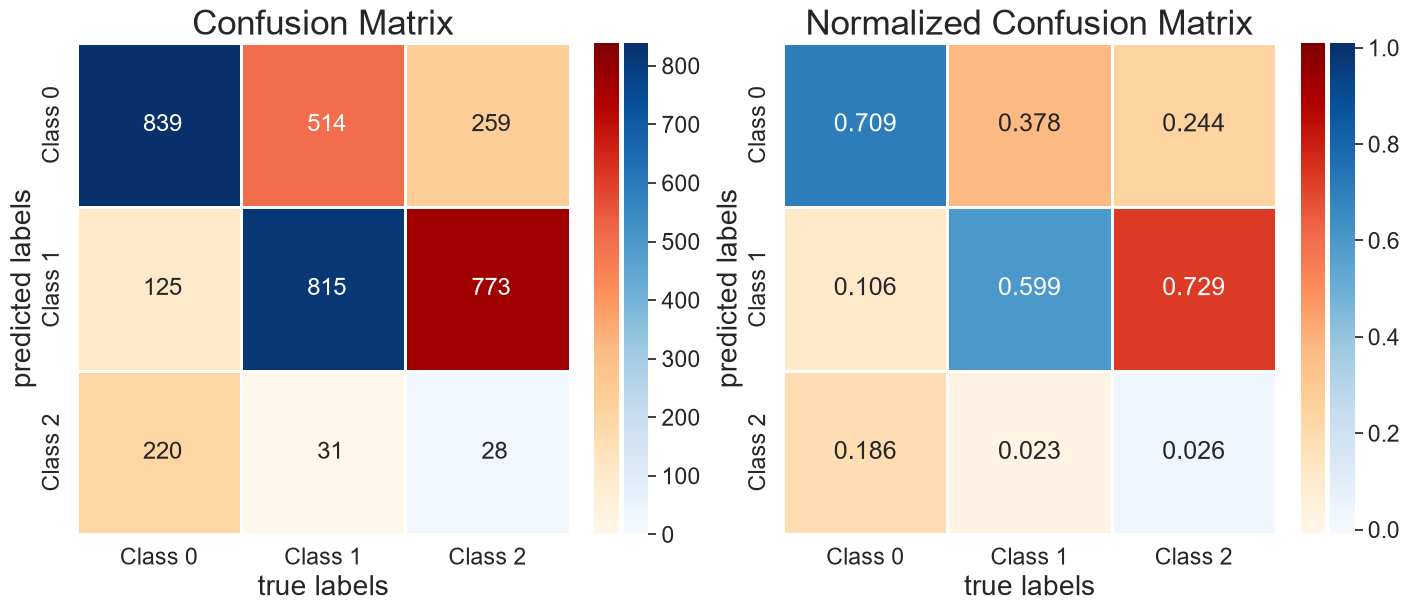

-- Evaluating saved model: xeegnet_scc version 200 at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v200.pt-- 


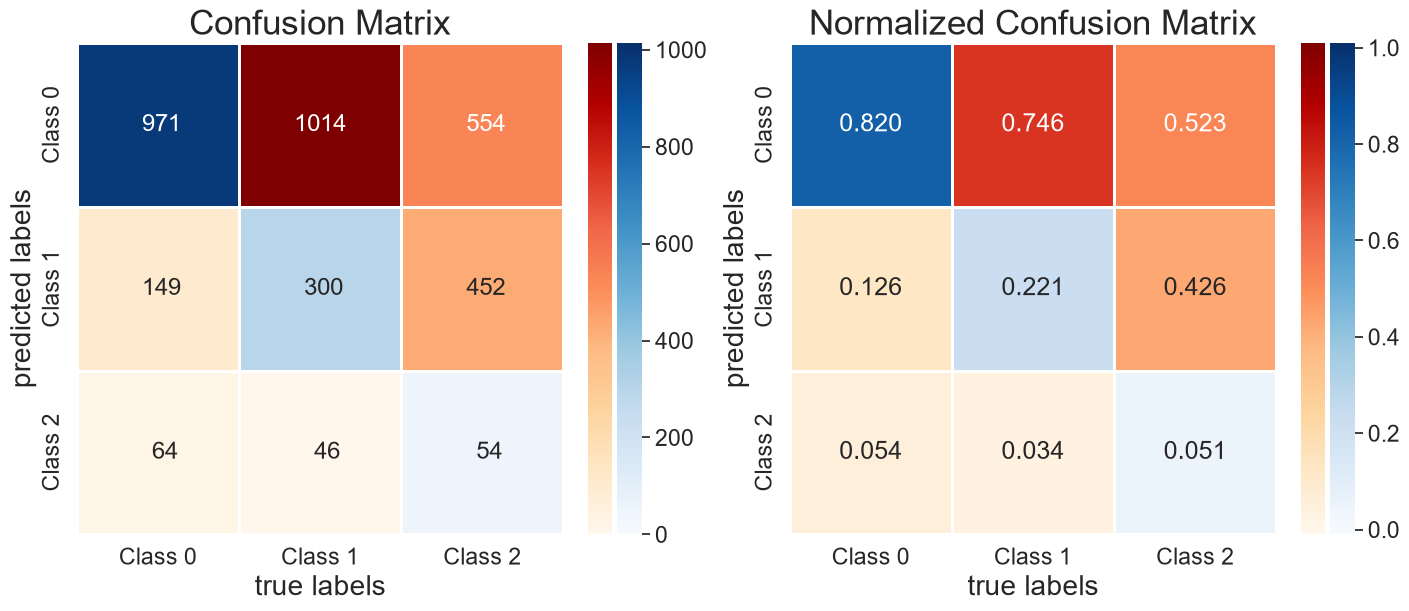

In [24]:
if True:
    model_versions = [200, 201, 202, 203, 204]
    model_versions = [200]
    # model_versions = [200, 201]
    model_kinds = ["xeegnet", "xeegnet_scc"]

    model_prefixes_bib = {"xeegnet": "xeegnet_model", "xeegnet_scc": "xeegnet_scc_model"}
    # model_prefixes = ["xeegnet_model", "xeegnet_scc_model"]

    eval_datasplits = ["test"]
    results_name = "xeegnet_scc_model_versions_200_204_metrics.csv"

    eval_datasplits = ["test", "val", "train"]
    results_name = "xeegnet_scc_model_versions_200_204_metrics_allsplits.csv"

    saved_model_runs = []

    for model_version in model_versions:
        for model_kind in model_kinds:
            model_prefix = model_prefixes_bib[model_kind]
            saved_model_runs.append(
                {
                    "model_kind": model_kind,
                    "model_path": PRETRAINED_MODEL_DIR / f"{model_prefix}_v{model_version}.pt",
                    # "model_path": PRETRAINED_MODEL_DIR / "pretrained_models_local_backup"  /  f"{model_prefix}_v{model_version}.pt",
                }
            )

    saved_model_results = []
    for run in saved_model_runs:
        saved_model_results.extend(evaluate_saved_model(run["model_path"], run["model_kind"]))

    saved_model_results_df = (
        pd.DataFrame(saved_model_results)
        .sort_values(["model_version", "model_kind", "datasplit"])
        .reset_index(drop=True)
    )

    saved_model_results_name = PRETRAINED_MODEL_DIR / results_name
    # saved_model_results_df.to_csv(saved_model_results_name, index=False)
    saved_model_results_df

In [25]:
# get the mean accuracy over all xeegnet_scc models, and all xeegnet models, for each datasplit
saved_model_results_df.groupby(["datasplit", "model_kind"])["accuracy"].mean()

datasplit  model_kind 
test       xeegnet        0.466704
           xeegnet_scc    0.367647
train      xeegnet        0.742373
           xeegnet_scc    0.309899
val        xeegnet        0.543677
           xeegnet_scc    0.375687
Name: accuracy, dtype: float64

### reducer mode node


In [ ]:
debug = False
if debug:
    # n_max_ = 500
    n_max_ = None
    max_epochs_ = 1
    save_model_flag_ = False
else:
    n_max_ = None
    max_epochs_ = max_epochs
    save_model_flag_ = True

# reducer_mode_scc_list = ["mean", "node", "edge"]
reducer_mode_scc_list = ["node"]
results_name = f"xeegnet_scc_reducer_modes_model_versions_200_204_metrics.csv"
model_kind = "xeegnet_scc"

if True:
    multi_model_results = []
    for reducer_mode_scc in reducer_mode_scc_list:
        for model_version in range(200, 205):

            print(f"Training and evaluating model version: {model_version} - modeltype: {model_kind} - reducer_mode_scc: {reducer_mode_scc}")

            run_result = train_and_evaluate_model_version(
                model_version=model_version,
                model_kind=model_kind,
                reducer_mode_scc=reducer_mode_scc,
                dir_data=dir_data,
                dir_data_outer=dir_data_outer,
                parameters=PARAMETERS_DEFAULT,
                nb_classes=nb_classes,
                Chans=Chans,
                sample_length=sample_length,
                srate=srate,
                device=device,
                lr=lr,
                verbose=verbose,
                task_to_eval=taskToEval,
                n_max=n_max_,
                train_epochs=max_epochs_,
                do_train=do_train,
                do_evaluate=False,
                save_model_flag=save_model_flag_,
                store=store,
                scc_params=scc_params,
                load_model_windows_for_participant=load_model_windows_for_participant,
                # data_x_y_id=data_x_y_id,
                data_x_y_scc_id=data_x_y_scc_id
            )
            run_result[0]['reducer_mode_scc'] = reducer_mode_scc

            multi_model_results.append(run_result)

    multi_model_results = list(chain.from_iterable(multi_model_results))
    results_df = pd.DataFrame(multi_model_results)
    results_df = results_df.sort_values("model_version").reset_index(drop=True)
    # print(results_df)

    metrics_csv_path = PRETRAINED_MODEL_DIR / results_name
    results_df.to_csv(metrics_csv_path, index=False)
    # print(f"Saved metrics to {metrics_csv_path}")

    results_df

Training and evaluating model version: 200 - modeltype: xeegnet_scc - reducer_mode_scc: node
epoch [1/100]
   val 52/52: 100%|███████████████| 224/224 [38.50 Batch/s, train_loss=2.00791, val_loss=1.44893]  
epoch [2/100]
   val 52/52: 100%|███████████████| 224/224 [45.32 Batch/s, train_loss=1.67852, val_loss=1.35138]  
epoch [3/100]
   val 52/52: 100%|███████████████| 224/224 [48.86 Batch/s, train_loss=1.46866, val_loss=1.28255]  
epoch [4/100]
   val 52/52: 100%|███████████████| 224/224 [50.67 Batch/s, train_loss=1.34709, val_loss=1.21043]  
epoch [5/100]
   val 52/52: 100%|███████████████| 224/224 [52.41 Batch/s, train_loss=1.24930, val_loss=1.19788]  
epoch [6/100]
   val 52/52: 100%|███████████████| 224/224 [51.85 Batch/s, train_loss=1.16573, val_loss=1.15104]  
epoch [7/100]
   val 52/52: 100%|███████████████| 224/224 [52.70 Batch/s, train_loss=1.09365, val_loss=1.15007]  
epoch [8/100]
   val 52/52: 100%|███████████████| 224/224 [54.08 Batch/s, train_loss=1.02619, val_loss=1.1576

-- Evaluating saved model: xeegnet_scc version 200 with reducer mode mean at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v200.pt-- 


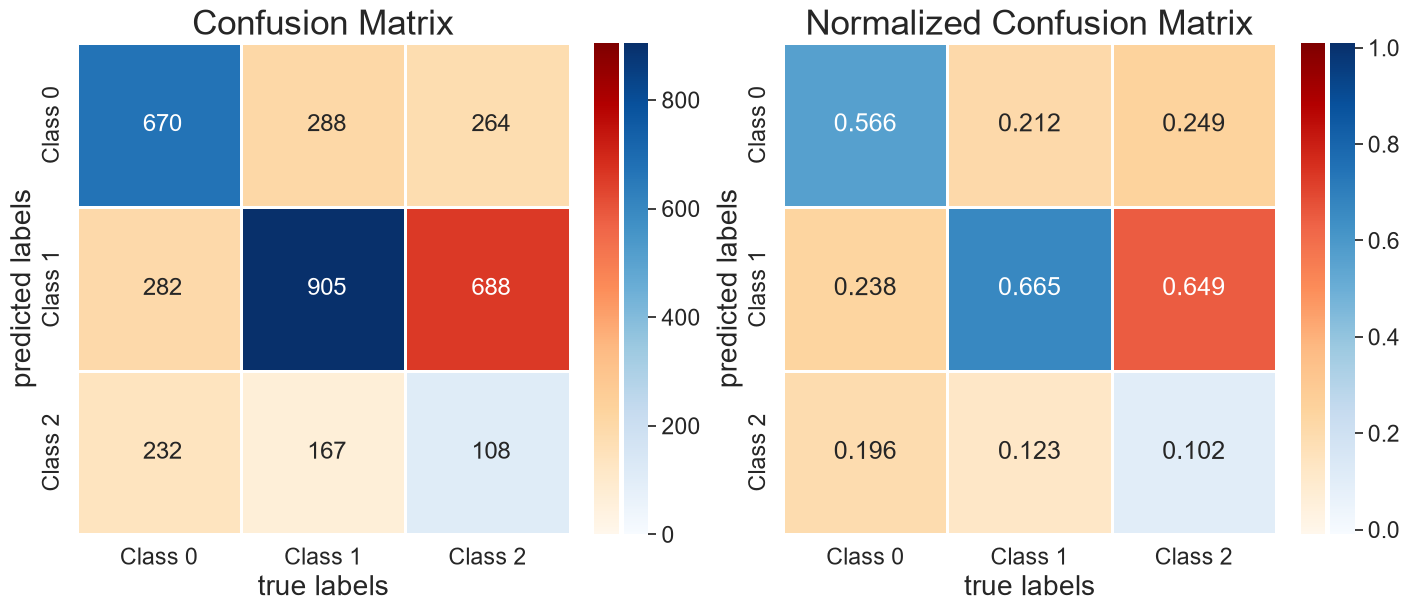

-- Evaluating saved model: xeegnet_scc version 200 with reducer mode node at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_node_v200.pt-- 


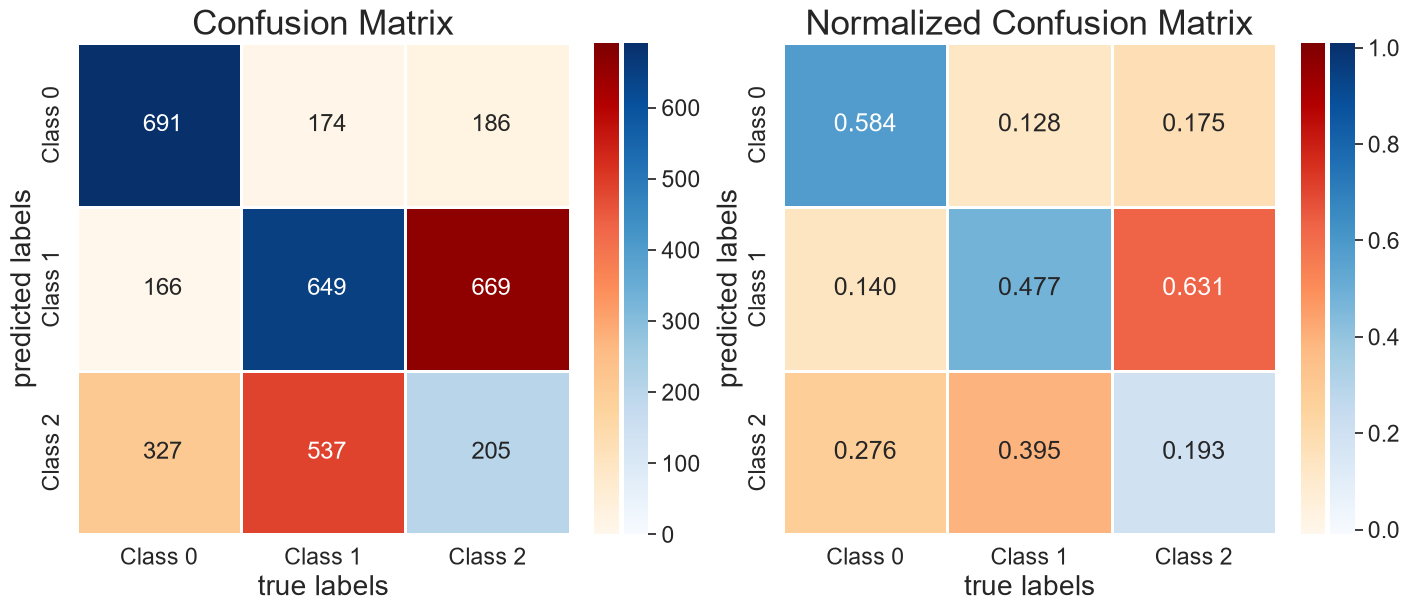

-- Evaluating saved model: xeegnet_scc version 200 with reducer mode edge at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_edge_v200.pt-- 


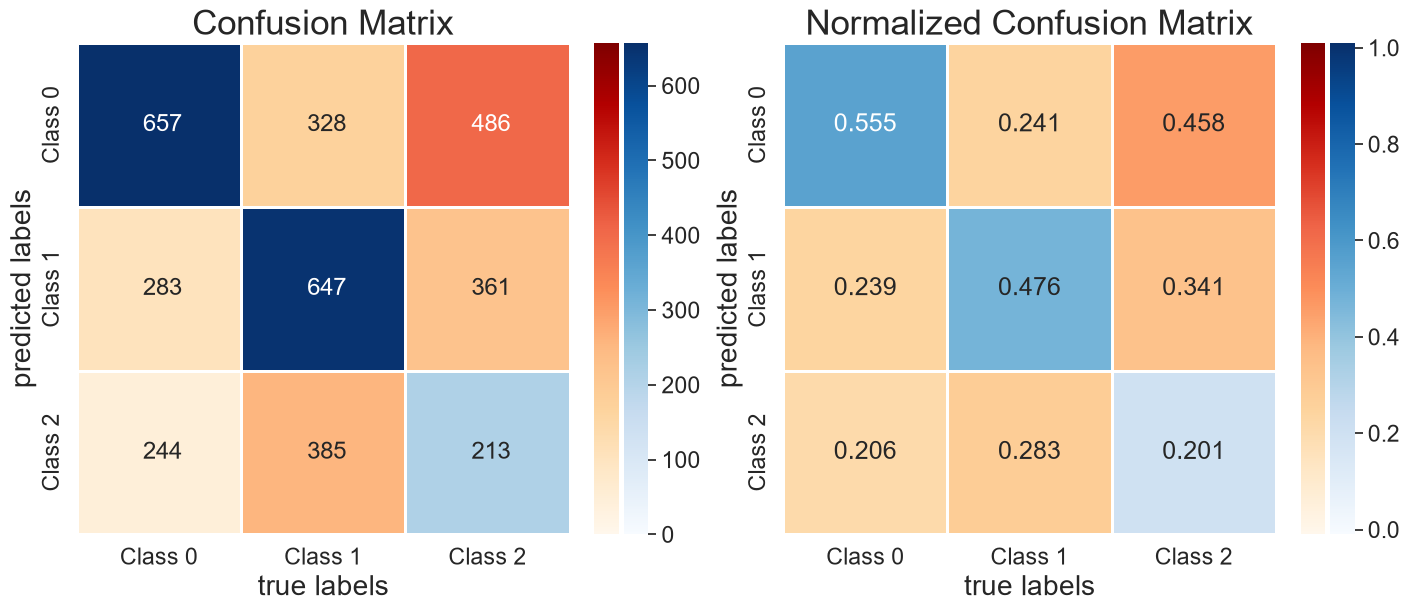

-- Evaluating saved model: xeegnet version 200 with reducer mode None at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt-- 


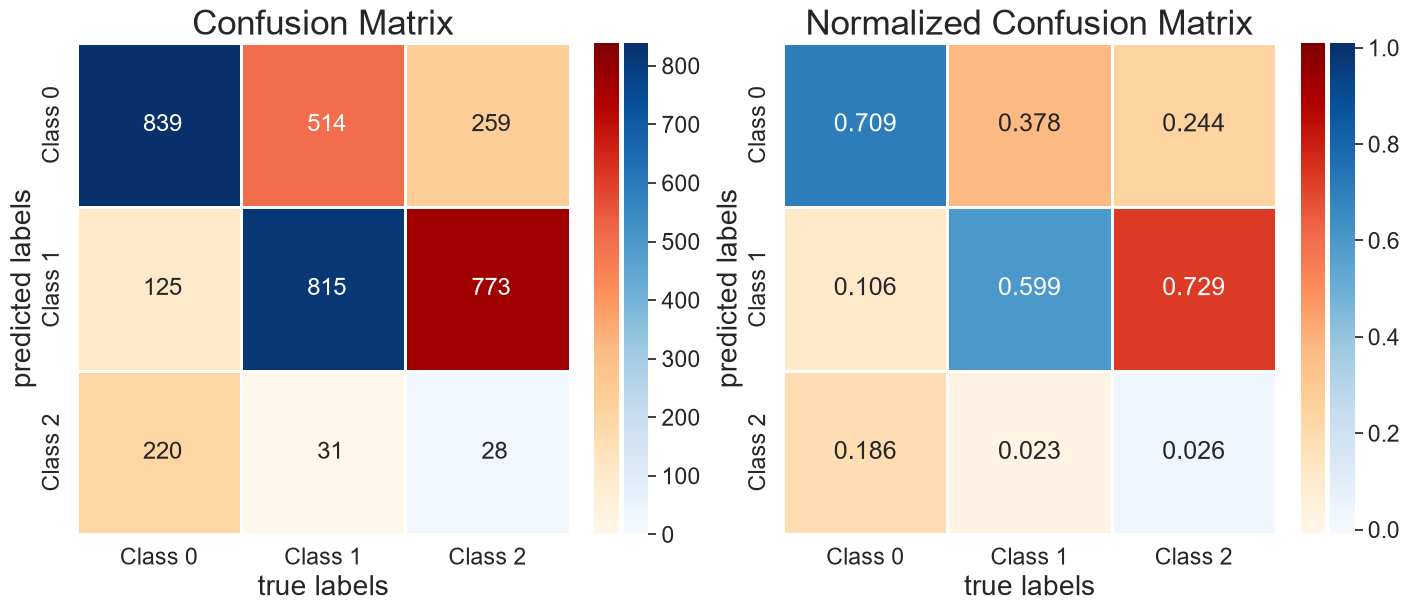

-- Evaluating saved model: xeegnet_scc version 201 with reducer mode mean at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v201.pt-- 


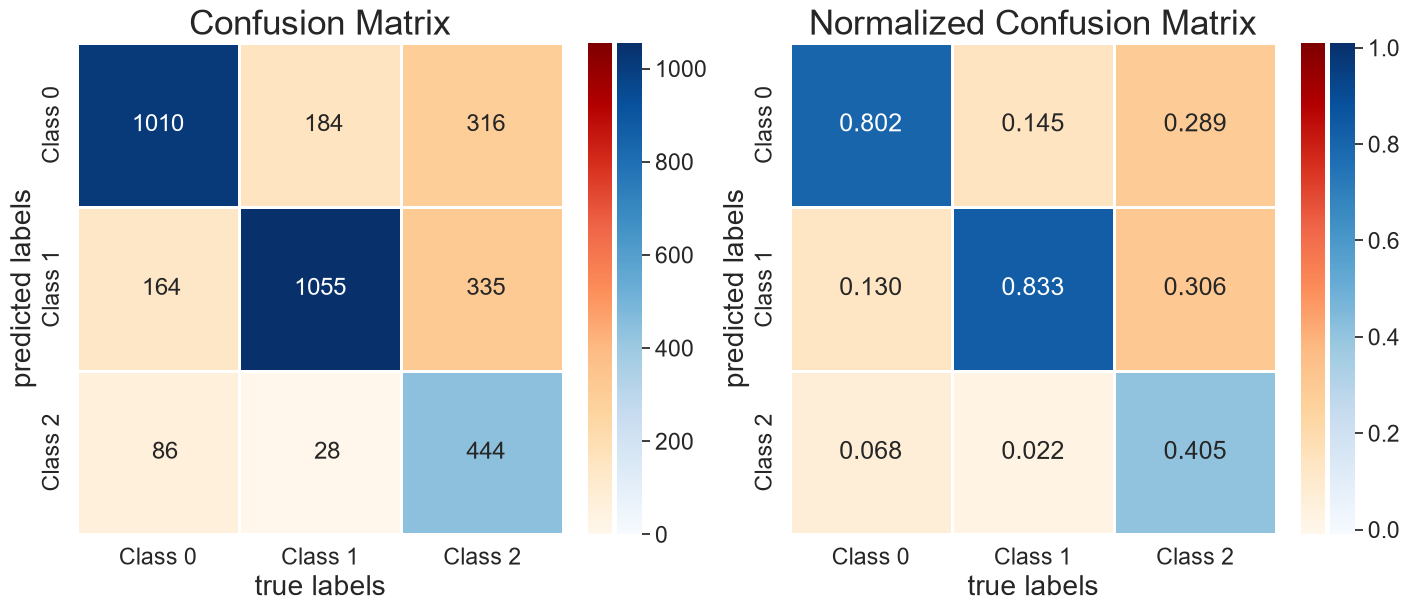

-- Evaluating saved model: xeegnet_scc version 201 with reducer mode node at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_node_v201.pt-- 


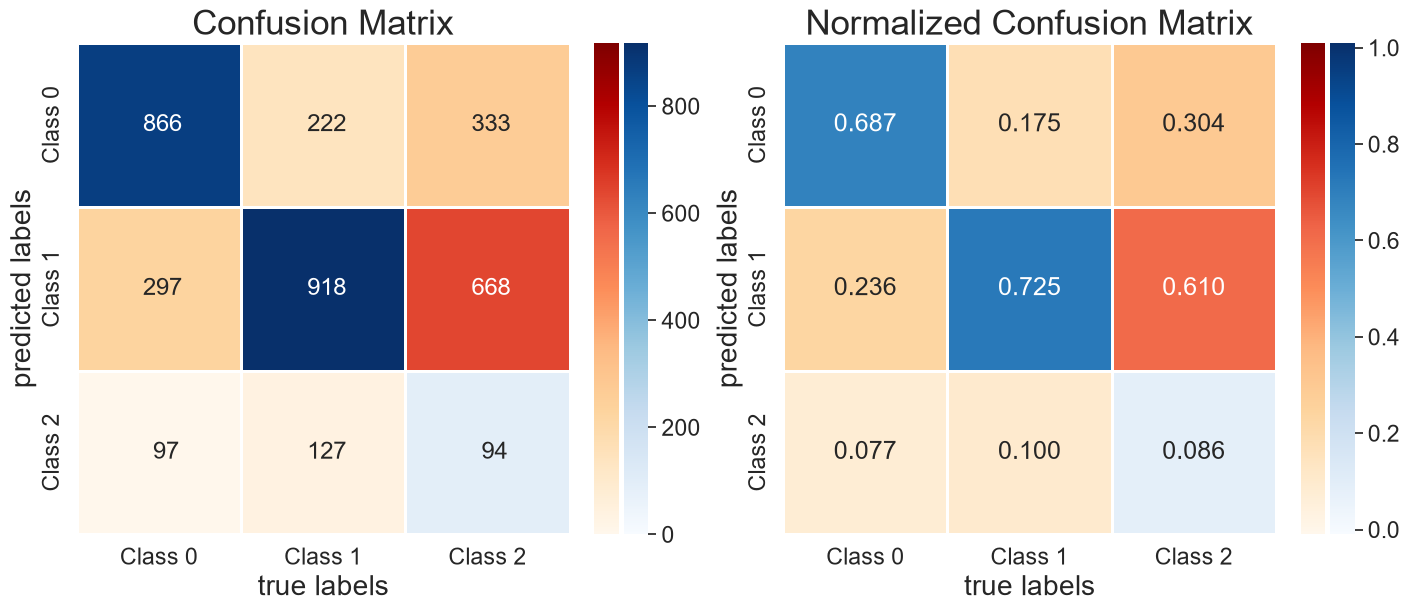

-- Evaluating saved model: xeegnet_scc version 201 with reducer mode edge at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_edge_v201.pt-- 


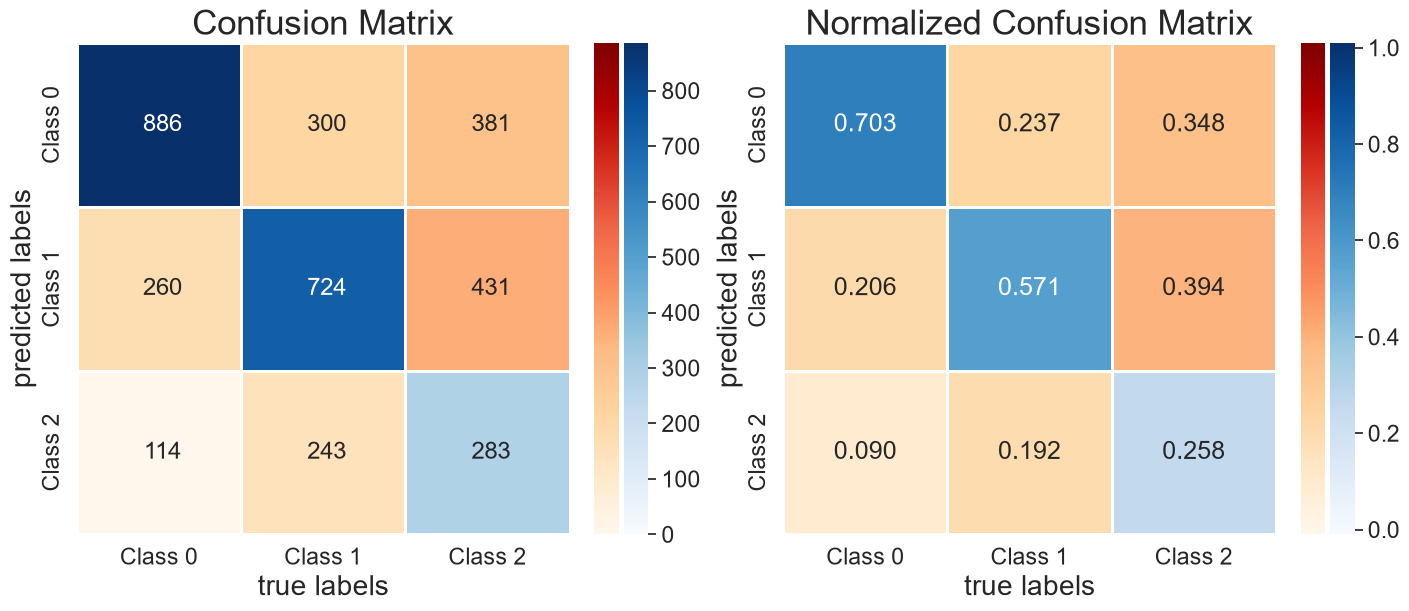

-- Evaluating saved model: xeegnet version 201 with reducer mode None at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v201.pt-- 


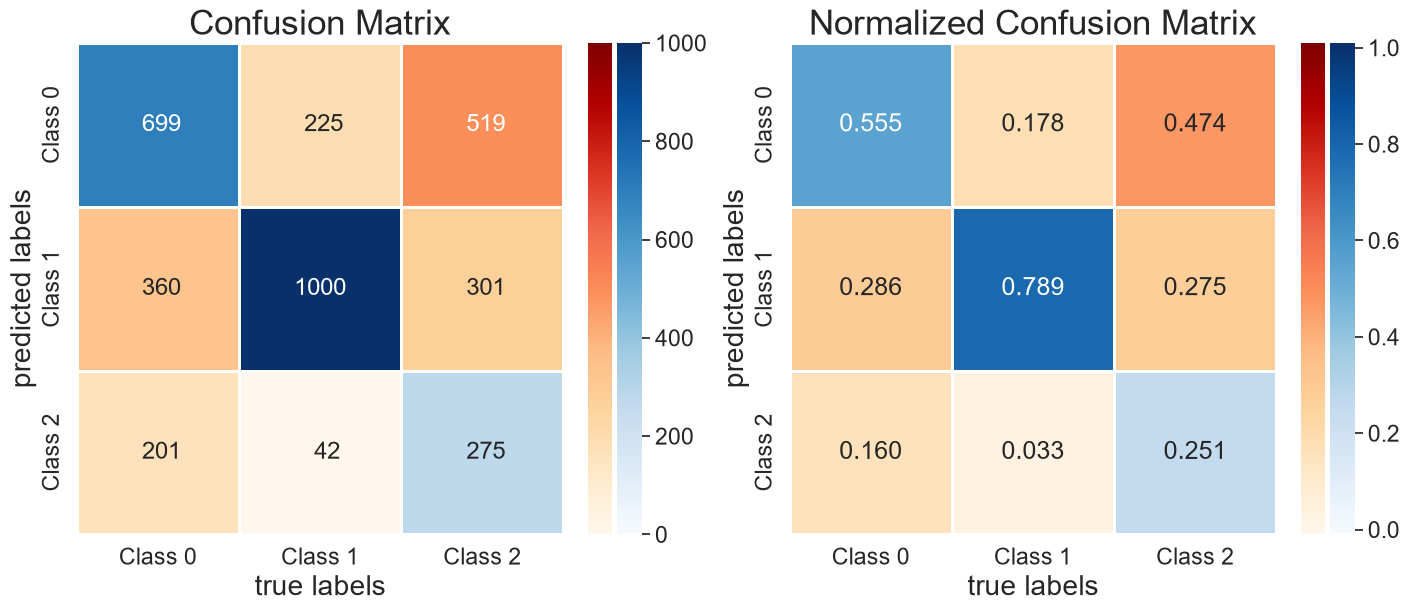

-- Evaluating saved model: xeegnet_scc version 202 with reducer mode mean at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v202.pt-- 


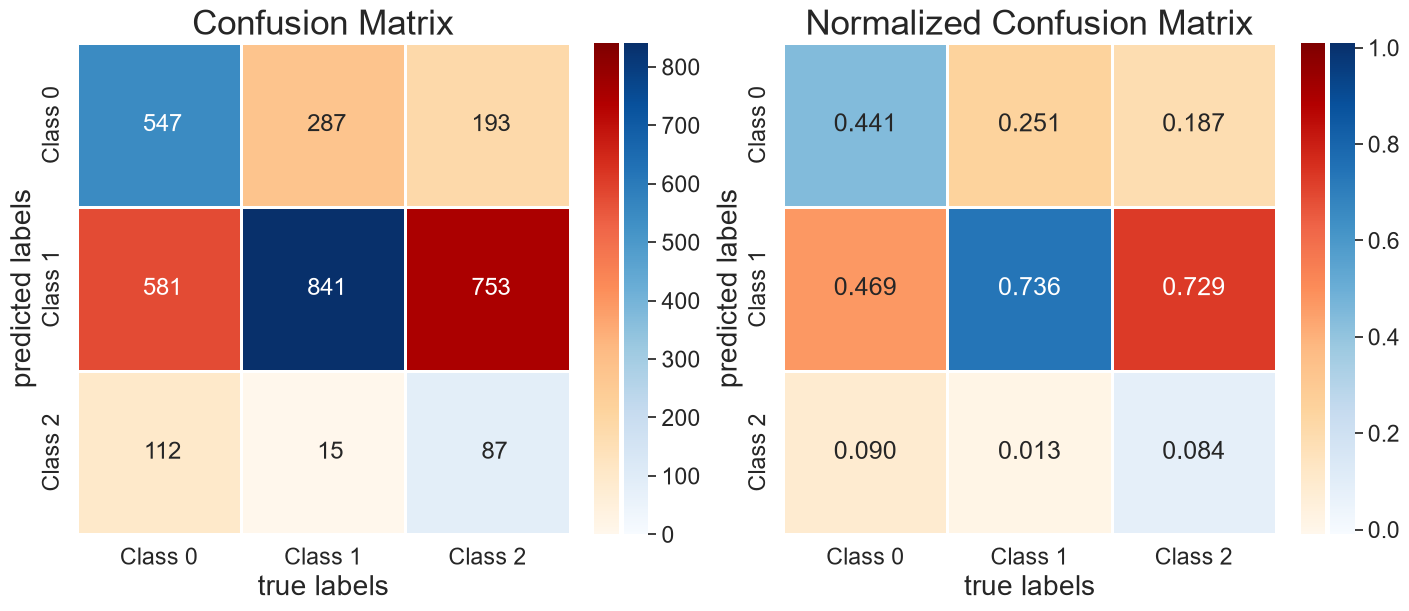

-- Evaluating saved model: xeegnet_scc version 202 with reducer mode node at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_node_v202.pt-- 


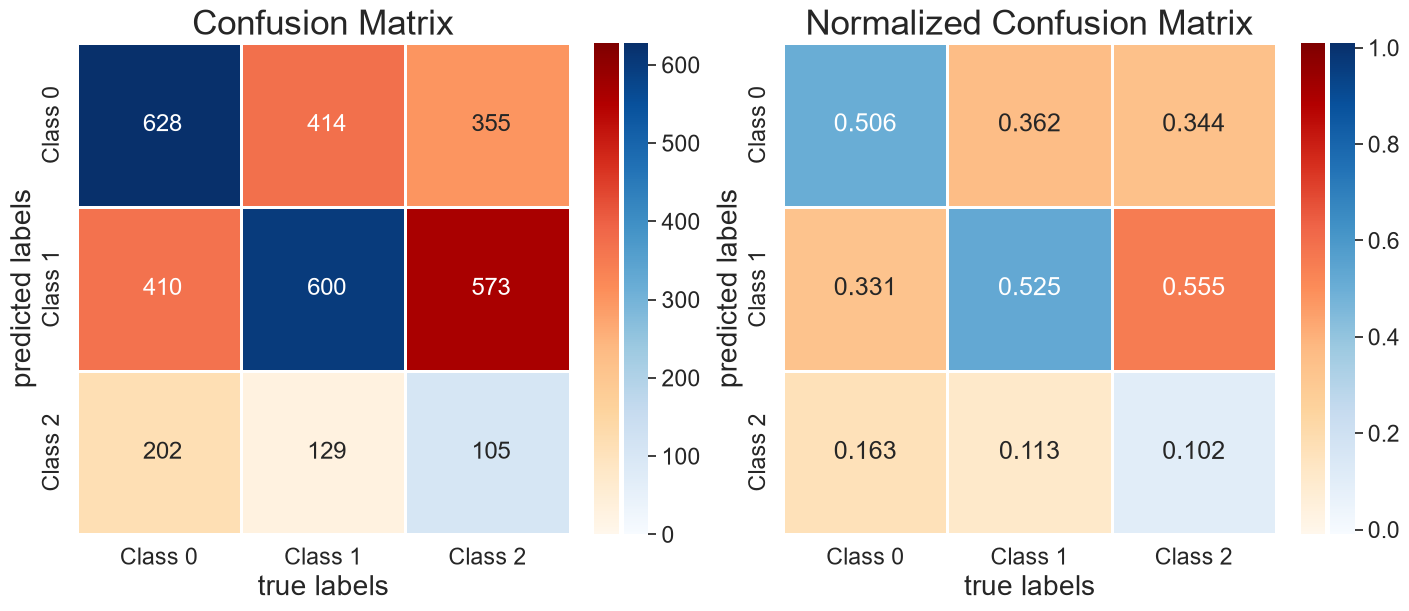

-- Evaluating saved model: xeegnet_scc version 202 with reducer mode edge at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_edge_v202.pt-- 


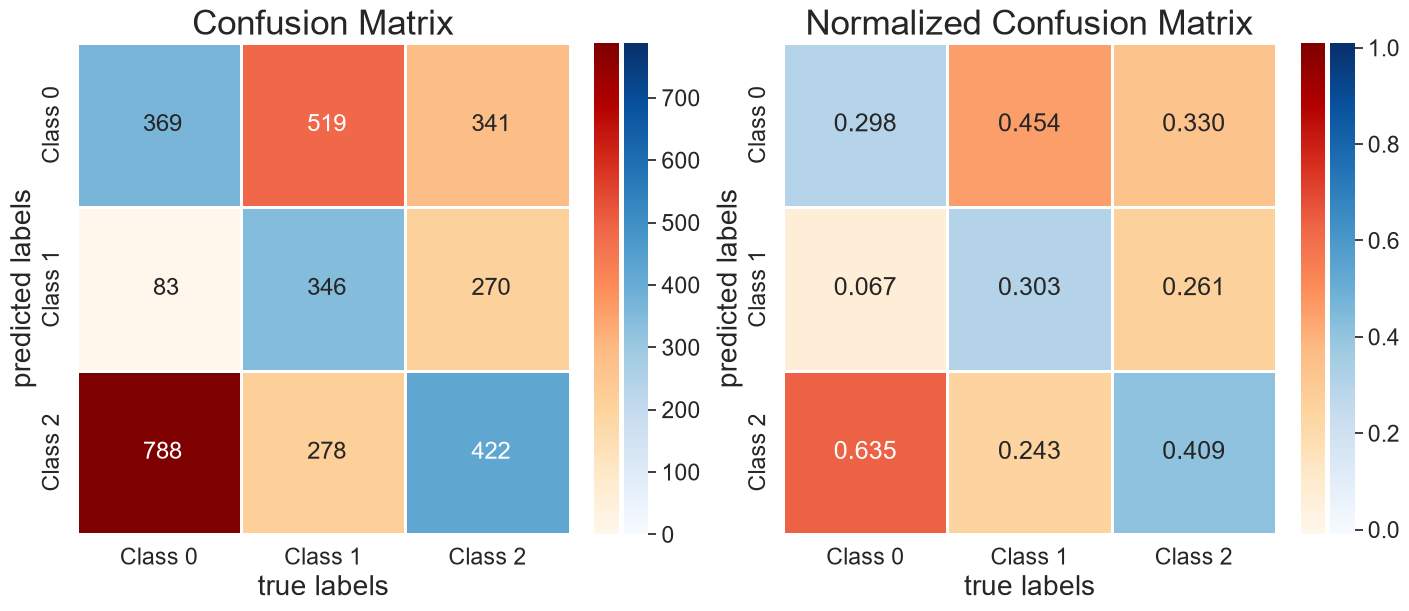

-- Evaluating saved model: xeegnet version 202 with reducer mode None at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v202.pt-- 


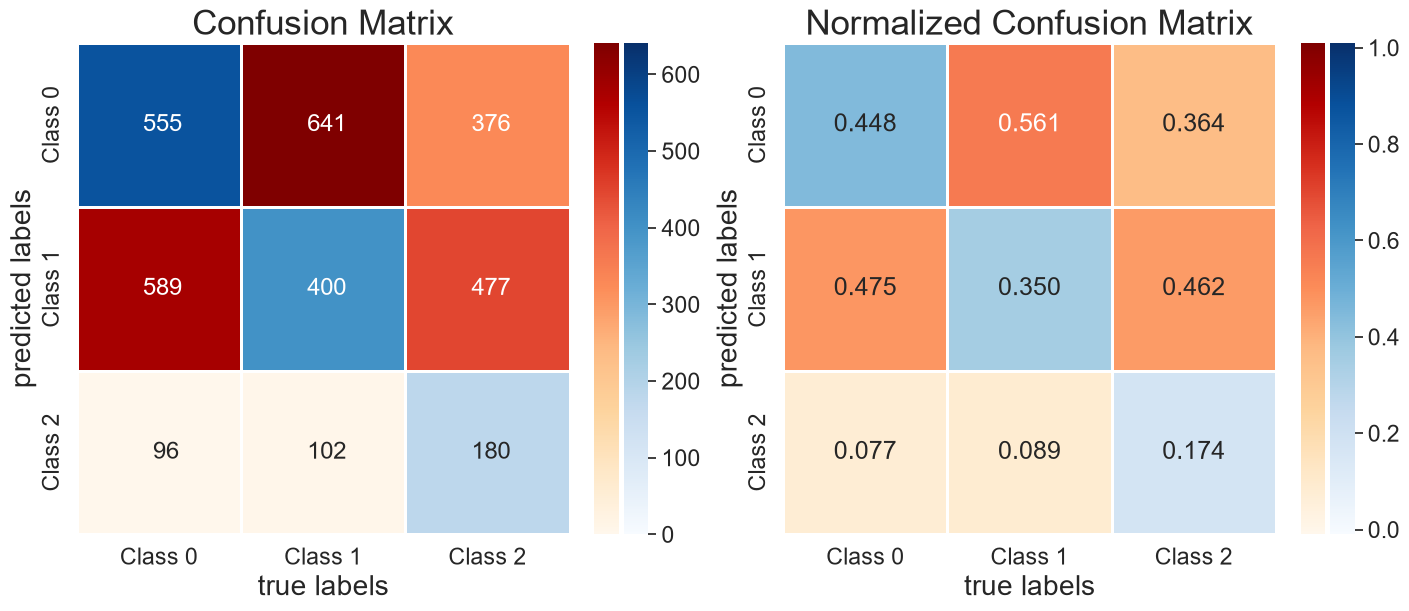

-- Evaluating saved model: xeegnet_scc version 203 with reducer mode mean at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v203.pt-- 


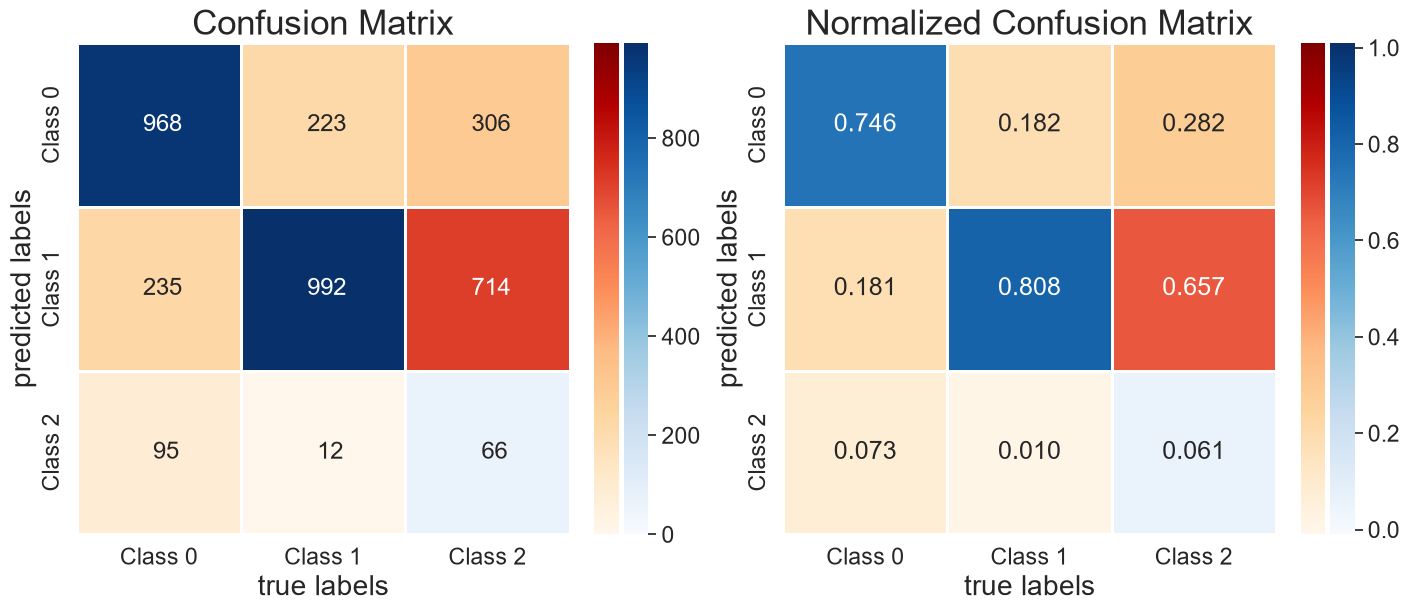

-- Evaluating saved model: xeegnet_scc version 203 with reducer mode node at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_node_v203.pt-- 


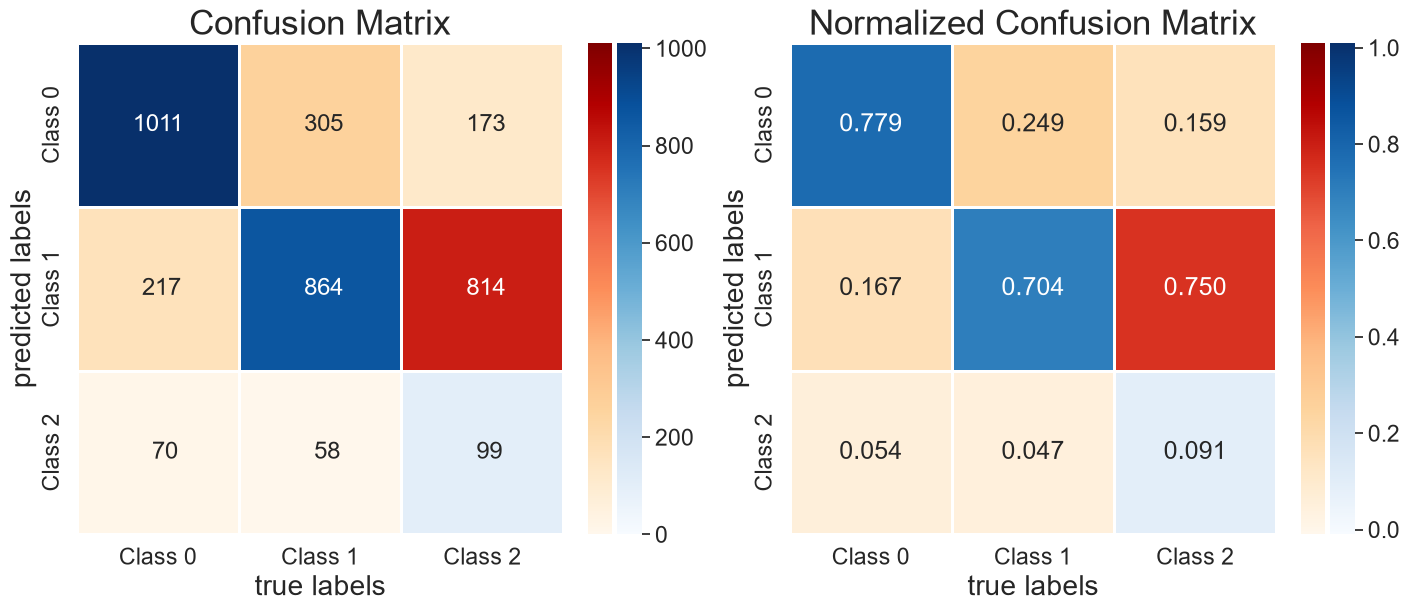

-- Evaluating saved model: xeegnet_scc version 203 with reducer mode edge at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_edge_v203.pt-- 


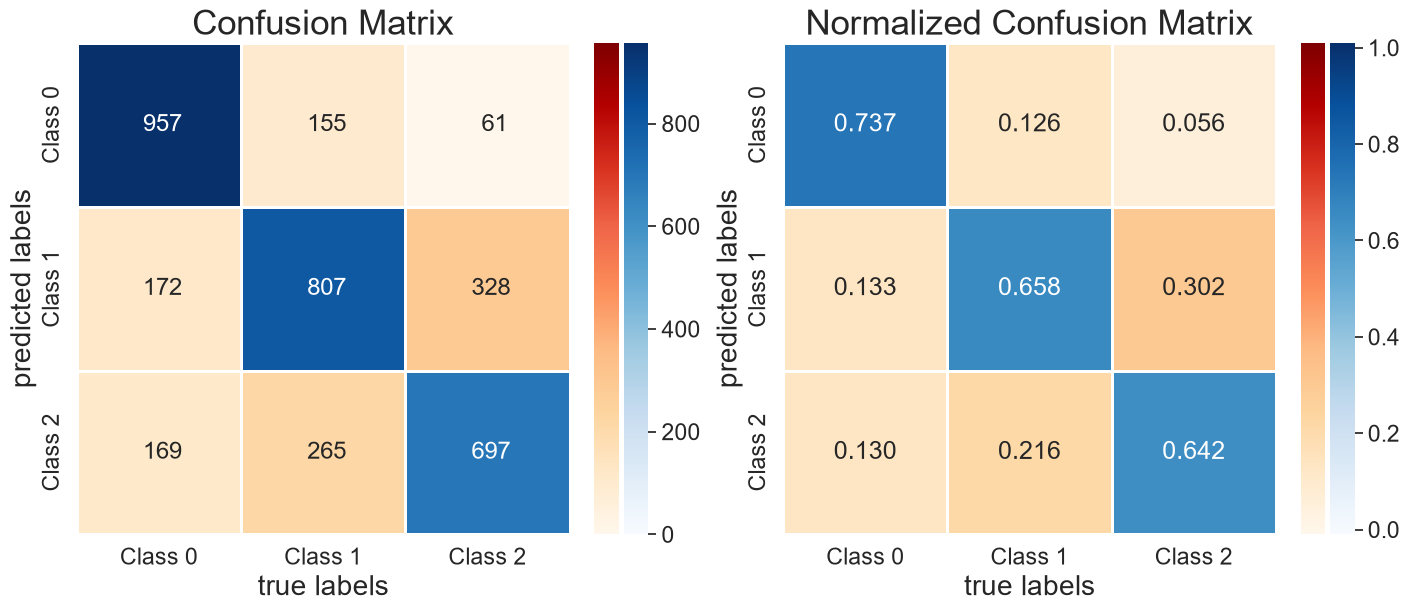

-- Evaluating saved model: xeegnet version 203 with reducer mode None at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v203.pt-- 


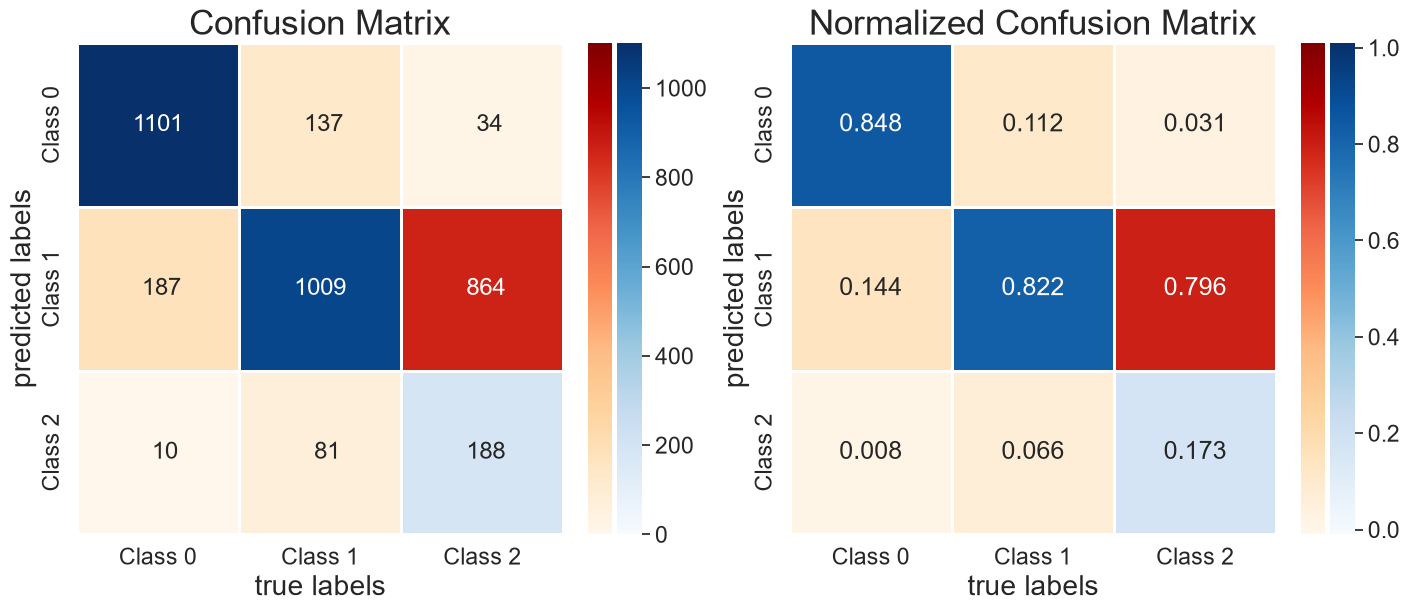

-- Evaluating saved model: xeegnet_scc version 204 with reducer mode mean at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v204.pt-- 


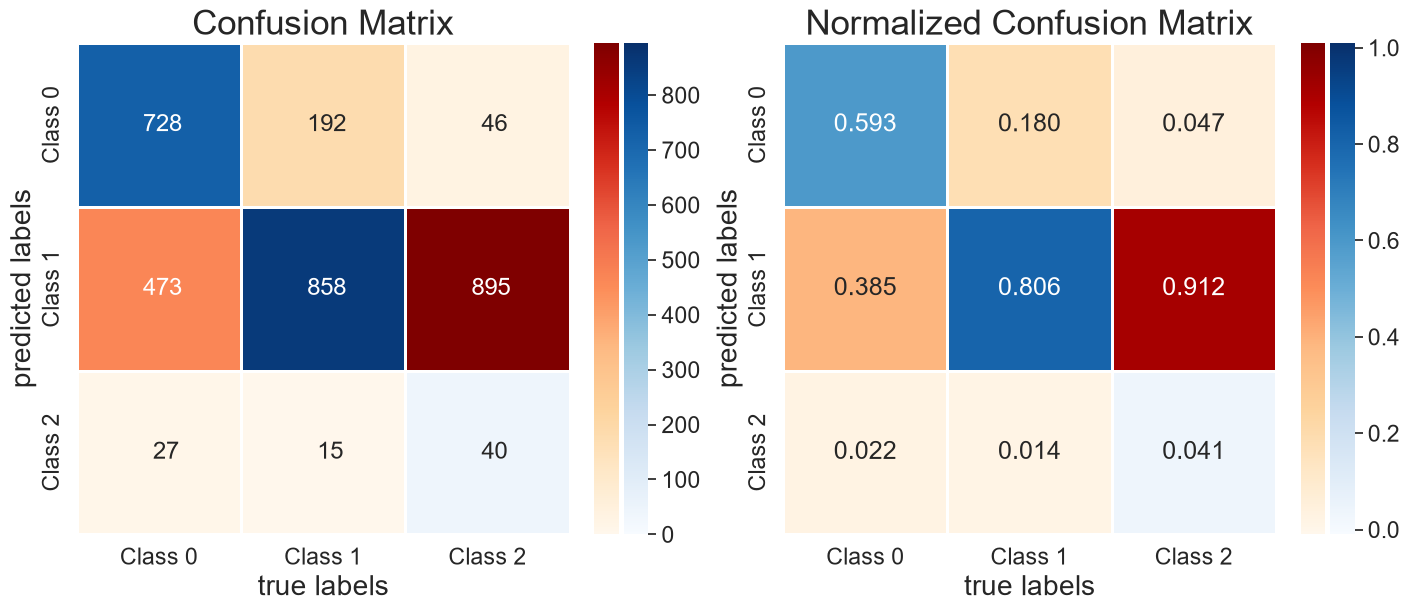

-- Evaluating saved model: xeegnet_scc version 204 with reducer mode node at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_node_v204.pt-- 


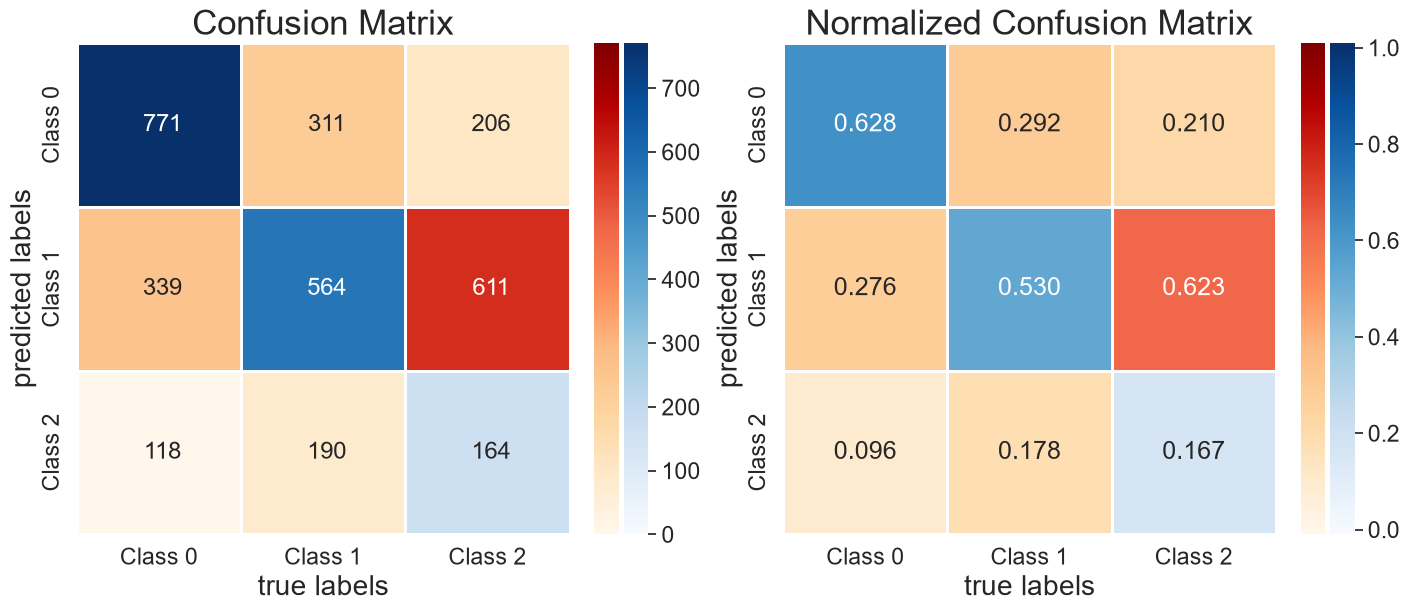

-- Evaluating saved model: xeegnet_scc version 204 with reducer mode edge at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_reducermode_edge_v204.pt-- 


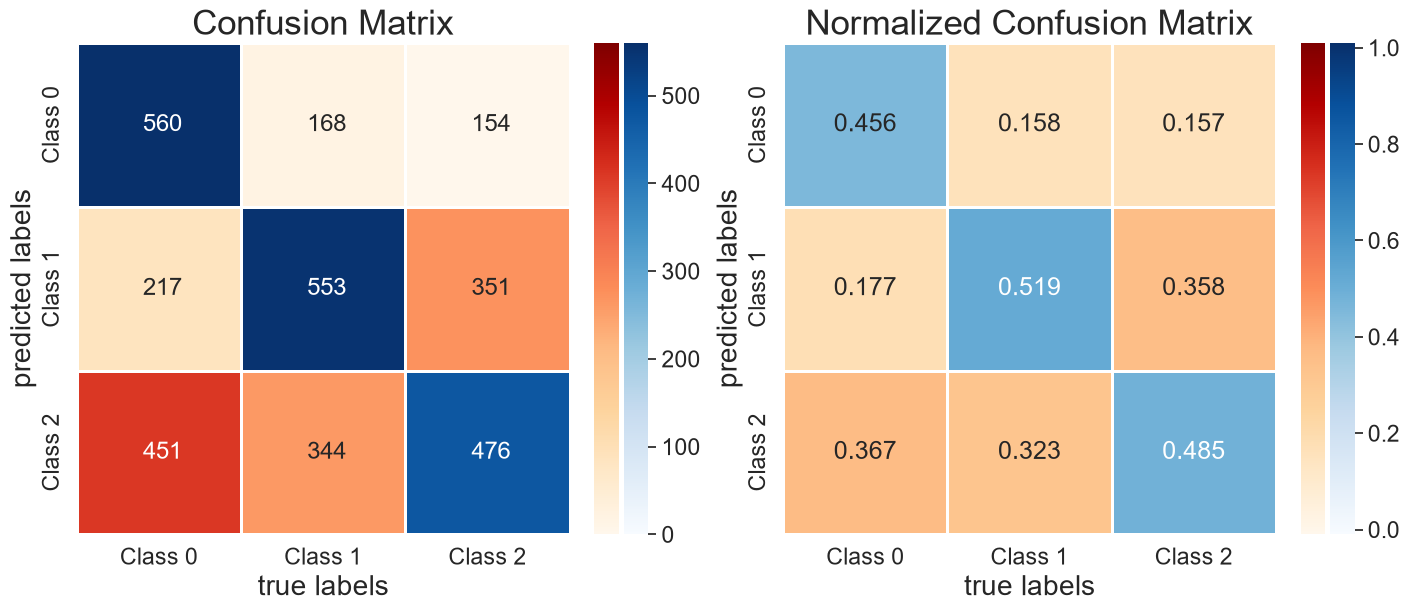

-- Evaluating saved model: xeegnet version 204 with reducer mode None at C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v204.pt-- 


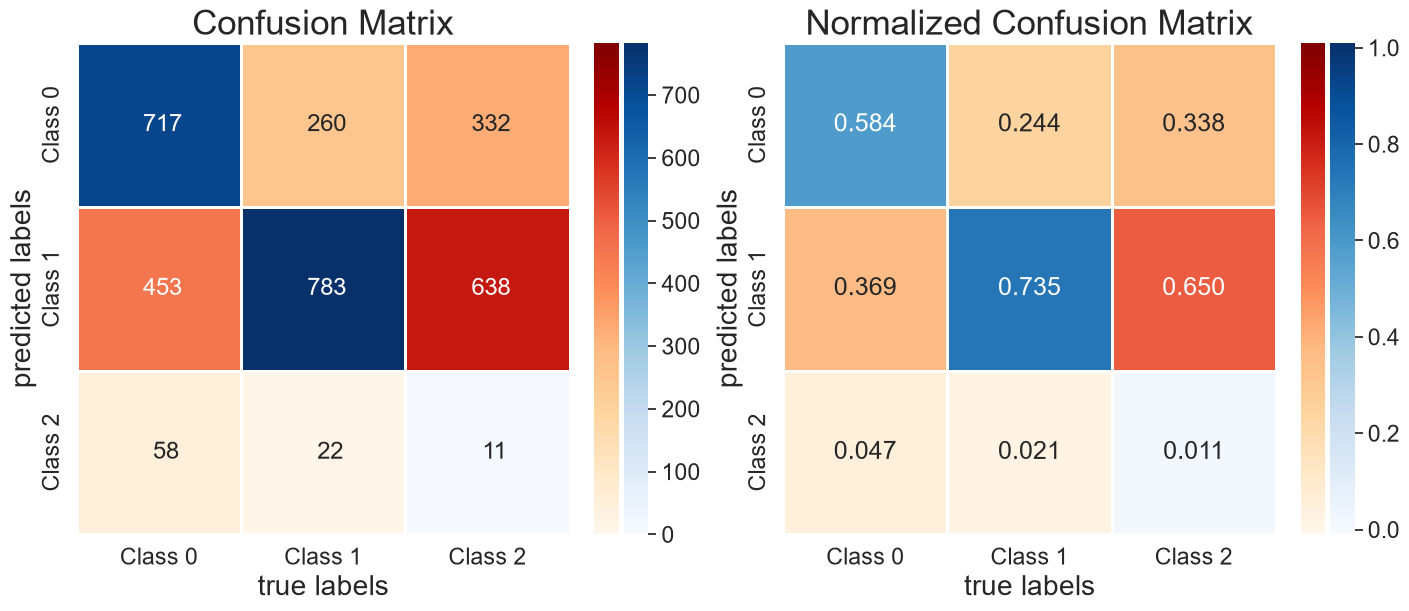

,model_version,model_kind,reducer_mode_scc,model_name,model_path,train_epochs,datasplit,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted
0,200,xeegnet,NaN,xeegnet_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.466704,0.444765,0.390797,0.409623,0.365534,0.380042,0.444765,0.466704
1,200,xeegnet,NaN,xeegnet_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,train,10981,0.742373,0.691996,0.693025,0.724179,0.754401,0.750414,0.691996,0.742373
2,200,xeegnet,NaN,xeegnet_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,val,3274,0.543677,0.520880,0.480006,0.500261,0.509492,0.521679,0.520880,0.543677
3,200,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.420921,0.410526,0.402336,0.412662,0.400255,0.410251,0.410526,0.420921
4,200,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,train,10981,0.933704,0.928574,0.930554,0.933590,0.933232,0.934038,0.928574,0.933704
5,200,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,val,3274,0.572083,0.555218,0.548422,0.562900,0.550681,0.562149,0.555218,0.572083
6,200,xeegnet_scc,mean,xeegnet_scc_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.466981,0.444402,0.418096,0.434645,0.414655,0.424914,0.444402,0.466981
7,200,xeegnet_scc,mean,xeegnet_scc_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,train,10981,0.757490,0.711421,0.718003,0.744975,0.754761,0.755744,0.711421,0.757490
8,200,xeegnet_scc,mean,xeegnet_scc_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,val,3274,0.562004,0.541573,0.507027,0.526710,0.566160,0.577638,0.541573,0.562004
9,200,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.428690,0.418072,0.422441,0.432008,0.428856,0.437427,0.418072,0.428690


In [ ]:
# model_versions = [200]
model_versions = [200, 201, 202, 203, 204]
# model_versions = [200, 201]
model_kinds = ["xeegnet_scc", "xeegnet"] #, "xeegnet"
# model_kinds = ["xeegnet_scc"] #, "xeegnet"
reducer_mode_scc_list = ["mean", "node", "edge"]
# reducer_mode_scc_list = ["node"]

model_prefixes_bib = {"xeegnet": "xeegnet_model", "xeegnet_scc": "xeegnet_scc_model"}
# model_prefixes = ["xeegnet_model", "xeegnet_scc_model"]

# eval_datasplits = ["test"]
# results_name = "xeegnet_scc_model_versions_200_204_metrics.csv"

eval_datasplits = ["test", "val", "train"] #, "val", "train"
results_name = "xeegnet_scc_model_versions_200_204_metrics_test.csv"

saved_model_runs = []

for model_version in model_versions:
    for model_kind in model_kinds:
        modes = reducer_mode_scc_list if model_kind == "xeegnet_scc" else [None]
        for reducer_mode_scc in modes:
            model_prefix = model_prefixes_bib[model_kind]

            model_name = generate_model_name(model_kind, model_version, n_max=None, reducer_mode_scc=reducer_mode_scc)
           
            saved_model_runs.append(
                {
                    "model_kind": model_kind,
                    "model_path": PRETRAINED_MODEL_DIR / model_name,
                    # "model_path": PRETRAINED_MODEL_DIR / "pretrained_models_local_backup"  /  f"{model_prefix}_v{model_version}.pt",
                    "reducer_mode_scc": reducer_mode_scc,
                }
            )

saved_model_results = []
for run in saved_model_runs:
    saved_model_results.extend(evaluate_saved_model(run["model_path"], run["model_kind"], reducer_mode_scc=run["reducer_mode_scc"]))

saved_model_results_df = (
    pd.DataFrame(saved_model_results)
    .sort_values(["model_version", "model_kind", "reducer_mode_scc", "datasplit"])
    .reset_index(drop=True)
)

saved_model_results_name = PRETRAINED_MODEL_DIR / results_name
# saved_model_results_df.to_csv(saved_model_results_name, index=False)
saved_model_results_df

In [48]:
saved_model_results_df.groupby(["datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["accuracy"].mean()

datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.488374
           xeegnet_scc  edge                0.488655
                        mean                0.529838
                        node                0.468385
train      xeegnet      NaN                 0.653865
           xeegnet_scc  edge                0.827716
                        mean                0.698453
                        node                0.674266
val        xeegnet      NaN                 0.482422
           xeegnet_scc  edge                0.526993
                        mean                0.492685
                        node                0.493969
Name: accuracy, dtype: float64

In [55]:
saved_model_results_df[saved_model_results_df["datasplit"] == "test"].groupby(["datasplit", "model_kind", "reducer_mode_scc"], dropna=False)["f1_weighted"].mean()

datasplit  model_kind   reducer_mode_scc
test       xeegnet      NaN                 0.449106
           xeegnet_scc  edge                0.485588
                        mean                0.486752
                        node                0.439656
Name: f1_weighted, dtype: float64

In [50]:
saved_model_results_df[saved_model_results_df["datasplit"] == "test"]

,model_version,model_kind,reducer_mode_scc,model_name,model_path,train_epochs,datasplit,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted
0,200,xeegnet,NaN,xeegnet_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.466704,0.444765,0.390797,0.409623,0.365534,0.380042,0.444765,0.466704
3,200,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.420921,0.410526,0.402336,0.412662,0.400255,0.410251,0.410526,0.420921
6,200,xeegnet_scc,mean,xeegnet_scc_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.466981,0.444402,0.418096,0.434645,0.414655,0.424914,0.444402,0.466981
9,200,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.428690,0.418072,0.422441,0.432008,0.428856,0.437427,0.418072,0.428690
12,201,xeegnet,NaN,xeegnet_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.545003,0.531723,0.513748,0.521945,0.539114,0.539611,0.531723,0.545003
15,201,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.522639,0.511017,0.497644,0.505535,0.506420,0.509356,0.511017,0.522639
18,201,xeegnet_scc,mean,xeegnet_scc_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.692711,0.679914,0.671470,0.677734,0.714489,0.710720,0.679914,0.692711
21,201,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.518498,0.499231,0.453978,0.468847,0.464182,0.471907,0.499231,0.518498
24,202,xeegnet,NaN,xeegnet_model_v202.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3416,0.332260,0.323929,0.318835,0.323042,0.367365,0.363454,0.323929,0.332260
27,202,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v202.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3416,0.332845,0.336271,0.336458,0.335445,0.359613,0.360375,0.336271,0.332845


In [38]:
saved_model_results_df.groupby(["datasplit", "model_kind"])["accuracy"].mean()

datasplit  model_kind 
test       xeegnet        0.505853
           xeegnet_scc    0.450363
Name: accuracy, dtype: float64

In [39]:
saved_model_results_df

,model_version,model_kind,reducer_mode_scc,model_name,model_path,train_epochs,datasplit,n_samples,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,precision_weighted,recall_macro,recall_weighted
0,200,xeegnet,NaN,xeegnet_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.466704,0.444765,0.390797,0.409623,0.365534,0.380042,0.444765,0.466704
1,200,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.485017,0.477685,0.458536,0.466049,0.467785,0.474303,0.477685,0.485017
2,200,xeegnet_scc,mean,xeegnet_scc_model_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.367647,0.363878,0.291742,0.297456,0.348222,0.348129,0.363878,0.367647
3,200,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v200.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3604,0.496670,0.479802,0.470237,0.484119,0.465647,0.476464,0.479802,0.496670
4,201,xeegnet,NaN,xeegnet_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.545003,0.531723,0.513748,0.521945,0.539114,0.539611,0.531723,0.545003
5,201,xeegnet_scc,edge,xeegnet_scc_model_reducermode_edge_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.481226,0.470417,0.454506,0.461816,0.462276,0.465115,0.470417,0.481226
6,201,xeegnet_scc,mean,xeegnet_scc_model_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.338763,0.338380,0.336971,0.339239,0.355290,0.359844,0.338380,0.338763
7,201,xeegnet_scc,node,xeegnet_scc_model_reducermode_node_v201.pt,C:\Users\grabn\Documents\CGV_2024\xeegVis_alll...,0,test,3622,0.532855,0.519860,0.505260,0.514569,0.515293,0.520105,0.519860,0.532855


## train & evaluate single models


In [70]:
# model = shallow_net
# model_curr = xeegnet
model_curr = build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate)


In [71]:
optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
gamma = 0.995
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# factor = 0.5
# patience_scheduler = 10
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=factor, patience=patience_scheduler)

# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(
    patience=15, min_delta=1e-04, record_best_weights=True
)

validation_loss_args = []
if taskToEval.casefold() == "alzheimer" or ("cognitive" in taskToEval.casefold()):
    lossFnc = lossMulti
else:
    lossFnc = lossBinary

In [72]:
# def load_participant_splits(split_path=None) -> dict[str, dict[str, list[int]]]:
#     if split_path is None:
#         split_path = Path("backend") / "ml" / "data_splits.json"
#     with split_path.open("r", encoding="utf-8") as file:
#         return json.load(file)

In [73]:
model_version = 200

n_max = 1500
n_max = None

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")


In [74]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
split_index = model_version - 200

if isinstance(model_curr, xEEGNetSCC):
    model_type = f"xeegnet_scc_model"
elif isinstance(model_curr, selfeeg.models.xEEGNet):
    model_type = f"xeegnet_model"
elif isinstance(model_curr, ShallowNet):
    model_type = f"shallownet_model"


if not n_max:
    modelname = f"{model_type}_v{model_version}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname
else:
    modelname = f"{model_type}_v{model_version}_nmax{n_max}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname

print(f"Model name: {modelname}")
print(f"Model path: {model_path}")

split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"

participants_split = load_participant_splits(split_path=split_path)[str(split_index)]

df_metadata = load_metadata(dir_data=dir_data)
df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"

participant_ids_train = participants_split["train"]
participant_ids_val = participants_split["val"]
participant_ids_test = participants_split["test"]

participant_ids_train_str = [gen_participant_id_long(pid) for pid in participant_ids_train]
participant_ids_val_str = [gen_participant_id_long(pid) for pid in participant_ids_val]
participant_ids_test_str = [gen_participant_id_long(pid) for pid in participant_ids_test]


Model name: xeegnet_scc_model_v200.pt
Model path: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v200.pt


In [75]:
# df_metadata, trainloader, valloader, testloader, xy = get_train_val_test_loader(
#     dir_data=dir_data,
#     df_metadata=df_metadata,
#     participant_ids_train=participants_split["train"],
#     participant_ids_val=participants_split["val"],
#     n_max=n_max
# )


# x_train, y_train, x_val, y_val, x_test, y_test = xy

In [76]:
# n_max

In [93]:
# check if model curr is scc

if isinstance(model_curr, xEEGNetSCC):
    print("model_curr is xEEGNetSCC; using cached SCC for dataloaders.")

    store  = SCCStore(
        root=Path(dir_data_outer) / "scc_cache" 
    )
    scc_params = SCCParams.default(sfreq=srate, sample_length=sample_length)

    trainloader, valloader, testloader, xy_subjects = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    participant_ids_test=participant_ids_test,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    n_max=n_max,
    use_cached_scc=True,
    store=store,
    scc_params=scc_params,
    dataset_id="ds004504",
    n_channels=Chans,
    source="derivatives",
    load_model_windows_for_participant=load_model_windows_for_participant,
)
else:
    trainloader, valloader, testloader, xy_subjects = get_dataloaders_xysubjectids(
        dir_data=dir_data,
        participant_ids_train=participant_ids_train,
        participant_ids_val=participant_ids_val,
        df_metadata=df_metadata,
        parameters=parameters,
        use_cached_scc=False,
        n_max=n_max,
    )

x_train, y_train, subject_ids_train, scc_train, x_val, y_val, subject_ids_val, scc_val, x_test, y_test, subject_ids_test, scc_test = xy_subjects

model_curr is xEEGNetSCC; using cached SCC for dataloaders.
Loaded derivative model windows: x shape (17859, 19, 500), y shape (17859,)
Loaded x (17859, 19, 500), scc (17859, 7, 171), y (17859,)


In [106]:
y_train

array([1, 1, 1, ..., 2, 2, 2], shape=(10981,))

In [108]:
y_train2

tensor([1, 1, 1,  ..., 0, 1, 1])

In [107]:
x_train2, y_train2 = get_x_y_from_loader(trainloader)

In [105]:
x_train

array([[[-44.810177  , -22.623198  , -12.431333  , ..., -10.761807  ,
          -8.434462  ,  -9.3336935 ],
        [-33.61159   , -16.673063  ,  -9.607849  , ..., -10.045416  ,
         -14.116623  , -13.487215  ],
        [ -9.109775  , -11.893477  , -15.592975  , ..., -24.2273    ,
         -31.043865  , -25.79072   ],
        ...,
        [-19.907846  , -13.372591  , -10.843512  , ..., -18.564726  ,
         -26.369976  , -23.199934  ],
        [-18.832417  , -13.146844  ,  -9.481776  , ..., -22.5467    ,
         -27.468716  , -24.69808   ],
        [-19.1118    , -12.684691  , -10.466578  , ..., -23.84007   ,
         -25.879204  , -19.75081   ]],

       [[-18.153572  , -25.151808  , -17.961424  , ..., -23.688705  ,
         -33.578606  , -29.502907  ],
        [-17.47351   , -24.608889  , -21.282913  , ..., -24.677813  ,
         -31.625275  , -30.083612  ],
        [-21.14333   , -30.513397  , -40.208694  , ..., -20.89838   ,
         -28.119602  , -29.32825   ],
        ...,


In [87]:
def get_x_y_from_loader(loader):
    x_batches = []
    y_batches = []

    for inputs, targets in loader:
        if isinstance(inputs, (list, tuple)):
            x_batch = inputs[0]
        else:
            x_batch = inputs

        x_batches.append(x_batch.cpu())
        y_batches.append(targets.cpu())

    x = torch.cat(x_batches, dim=0)
    y = torch.cat(y_batches, dim=0)
    return x,y


In [ ]:
# get x_train from trainloader
x_train

NameError: name 'trainloader' is not defined

In [113]:
loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=100,
    optimizer=optimizer,
    loss_func=lossFnc,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

save_model(model_curr, model_path)

epoch [1/100]
   val 52/52: 100%|███████████████| 224/224 [57.80 Batch/s, train_loss=2.57971, val_loss=2.35622]  
epoch [2/100]
   val 52/52: 100%|███████████████| 224/224 [58.46 Batch/s, train_loss=2.21775, val_loss=1.95927]  
epoch [3/100]
   val 52/52: 100%|███████████████| 224/224 [59.36 Batch/s, train_loss=1.93654, val_loss=1.67259]  
epoch [4/100]
   val 52/52: 100%|███████████████| 224/224 [59.67 Batch/s, train_loss=1.73289, val_loss=1.56308]  
epoch [5/100]
   val 52/52: 100%|███████████████| 224/224 [59.23 Batch/s, train_loss=1.59760, val_loss=1.44505]  
epoch [6/100]
   val 52/52: 100%|███████████████| 224/224 [60.58 Batch/s, train_loss=1.48459, val_loss=1.34726]  
epoch [7/100]
   val 52/52: 100%|███████████████| 224/224 [60.06 Batch/s, train_loss=1.39905, val_loss=1.29317]  
epoch [8/100]
   val 52/52: 100%|███████████████| 224/224 [58.36 Batch/s, train_loss=1.32774, val_loss=1.25080]  
epoch [9/100]
   val 52/52: 100%|███████████████| 224/224 [59.46 Batch/s, train_loss=1.2

## Evaluate model


In [64]:
def get_performances_metrics(y_true, y_pred):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
    }
    return metrics

In [160]:
from backend.ml.model import build_xeegnet

In [65]:
# model = model_curr

In [166]:
print(f"model version {model_version} ")
print(f"n_max: {n_max} ")

reload = True

n_max = None

# model_type = "xeegnet_scc"
model_type = "xeegnet"

if n_max:
    model_name = f"{model_type}_model_v{model_version}_nmax{n_max}.pt"
else:
    model_name = f"{model_type}_model_v{model_version}.pt"

model_path = PRETRAINED_MODEL_DIR / model_name
print(f"model path: {model_path}")

if reload:
    print(f"Reloading model from {model_path}...")
    if model_type == "xeegnet":
        model = build_xeegnet()

    elif model_type == "xeegnet_scc":
        model = build_xeegnet_scc()

    model = load_model_weights(model_path, model=model, device=device)

else:
    model = model_curr


model version 200 
n_max: None 
model path: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt
Reloading model from C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt...
Loading model from C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_curr = model_curr.to(device)
model_curr = model

# cast from torch.cuda.FloatTensor to torch.FloatTensor
# x_train_eeg = torch.Tensor(x_train)
# x_train = x_train.to(device)

if isinstance(model_curr, xEEGNetSCC):
    print("Evaluating xEEGNetSCC with cached SCC inputs.")
    eval_store = store
    eval_params = scc_params
    eval_df = load_metadata(dir_data)
    eval_label_of = {f"sub-{int(r.participant_id.split('-')[1]):03d}": int(r.group_encoded) for r in eval_df.itertuples()}

    def eval_split(participant_ids: list[int], split_name: str):
        x_eval, y_eval, scc_eval, _ = build_x_y_scc(
            dir_data,
            participant_ids,
            eval_label_of,
            eval_store,
            eval_params,
            load_model_windows_for_participant,
            dataset_id="ds004504",
            n_channels=Chans,
            source="derivatives",
            sample_length=sample_length,
        )
        x_eval_t = torch.as_tensor(x_eval, dtype=torch.float32, device=device)
        scc_eval_t = torch.as_tensor(scc_eval, dtype=torch.float32, device=device)
        with torch.no_grad():
            y_out = model_curr([x_eval_t, scc_eval_t])
        y_pred = torch.argmax(y_out, dim=1).detach().cpu().numpy()
        metrics = get_performances_metrics(y_eval, y_pred)
        print(f"Evaluating on {split_name} set:")
        print(metrics)
        print("\n") 

    eval_split(participant_ids_train, "train")
    eval_split(participant_ids_val, "val")
    eval_split(participant_ids_test, "test")
else:
    for dataset_type, x_data, y_data in zip(
        ["train", "val", "test"], [x_train, x_val, x_test], [y_train, y_val, y_test]
    ):
        print(f"Evaluating on {dataset_type} set:")
        x_data = torch.Tensor(x_data)
        x_data = x_data.to(device)
        with torch.no_grad():
            y_out = model_curr(x_data)
        y_pred = torch.argmax(y_out, dim=1).detach().cpu().numpy()
        metrics = get_performances_metrics(y_data, y_pred)
        print(metrics)
        print("\n")

Evaluating on train set:
{'accuracy': 0.7423731900555505, 'f1_macro': 0.6930250193508659, 'precision_macro': 0.7544014161026631, 'recall_macro': 0.6919962821579189}


Evaluating on val set:
{'accuracy': 0.5436774587660355, 'f1_macro': 0.48000562396124496, 'precision_macro': 0.5094921488241387, 'recall_macro': 0.5208795765692115}


Evaluating on test set:
{'accuracy': 0.5300252844500632, 'f1_macro': 0.42312599895775227, 'precision_macro': 0.4136975828519291, 'recall_macro': 0.4483254483135887}




           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.530  |
           |  Accuracy score weighted:        0.448  |
           |-----------------------------------------|
           |  Precision score micro:          0.530  |
           |  Precision score macro:          0.414  |
           |  Precision score weighted:       0.485  |
           |-----------------------------------------|
           |  Recall score micro:             0.530  |
           |  Recall score macro:             0.448  |
           |  Recall score weighted:          0.530  |
           |-----------------------------------------|
           |  F1-score micro:                 0.530  |
           |  F1-score macro:                 0.423  |
           |  F1-score weighted:              0.500  |
           |-----------------------------------------|
          

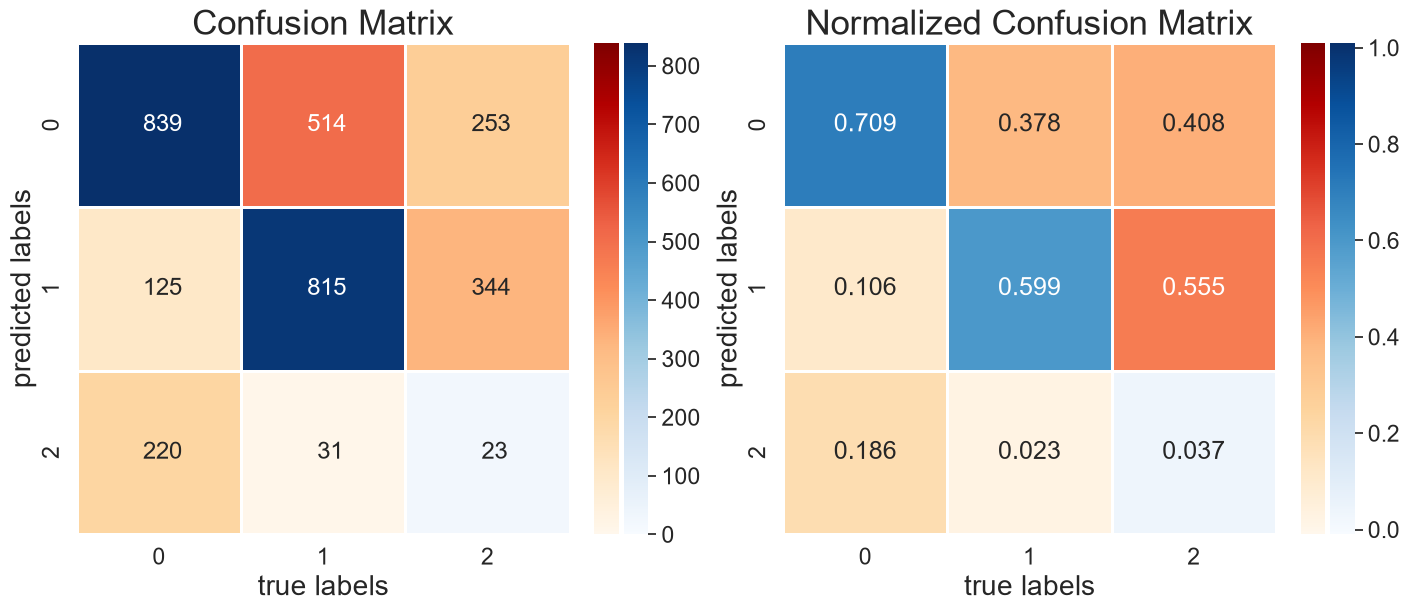

Balanced Accuracy:  44.83 %


In [ ]:
classlabels = y_test

# testloader_scc = 

if isinstance(model_curr, xEEGNetSCC):
    scores = get_performances(
        loader2eval=testloader_scc,
        Model=model_curr,
        device=device,
        nb_classes=nb_classes,
        return_scores=True,
        verbose=verbose,
        plot_confusion=True,
        class_labels=classlabels,
    )
else:
    scores = get_performances(
        loader2eval=testloader,
        Model=model_curr,
        device=device,
        nb_classes=nb_classes,
        return_scores=True,
        verbose=verbose,
        plot_confusion=True,
        class_labels=classlabels,
    )
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

#### shallow net 2


In [ ]:
if False:
    loss_summary = train_model(
        model=shallow_net_2,
        train_dataloader=trainloader,
        epochs=30,
        optimizer=optimizer,
        loss_func=lossFnc,
        lr_scheduler=scheduler,
        EarlyStopper=earlystop,
        validation_dataloader=valloader,
        validation_loss_func=lossVal,
        validation_loss_args=validation_loss_args,
        verbose=verbose,
        device=device,
        return_loss_info=True,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    shallow_net = shallow_net.to(device)

    # cast from torch.cuda.FloatTensor to torch.FloatTensor
    # x_train_eeg = torch.Tensor(x_train)
    x_train = x_train.to(device)
    y_train_out = shallow_net(x_train)
    y_train_pred = torch.argmax(y_train_out, dim=1).detach().cpu().numpy()

    print("ShallowNet 2 performance on training set:")
    get_performances_metrics(y_train, y_train_pred)

## Scores


           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.167  |
           |  Accuracy score weighted:        0.167  |
           |-----------------------------------------|
           |  Precision score micro:          0.167  |
           |  Precision score macro:          0.083  |
           |  Precision score weighted:       0.083  |
           |-----------------------------------------|
           |  Recall score micro:             0.167  |
           |  Recall score macro:             0.167  |
           |  Recall score weighted:          0.167  |
           |-----------------------------------------|
           |  F1-score micro:                 0.167  |
           |  F1-score macro:                 0.111  |
           |  F1-score weighted:              0.111  |
           |-----------------------------------------|
          

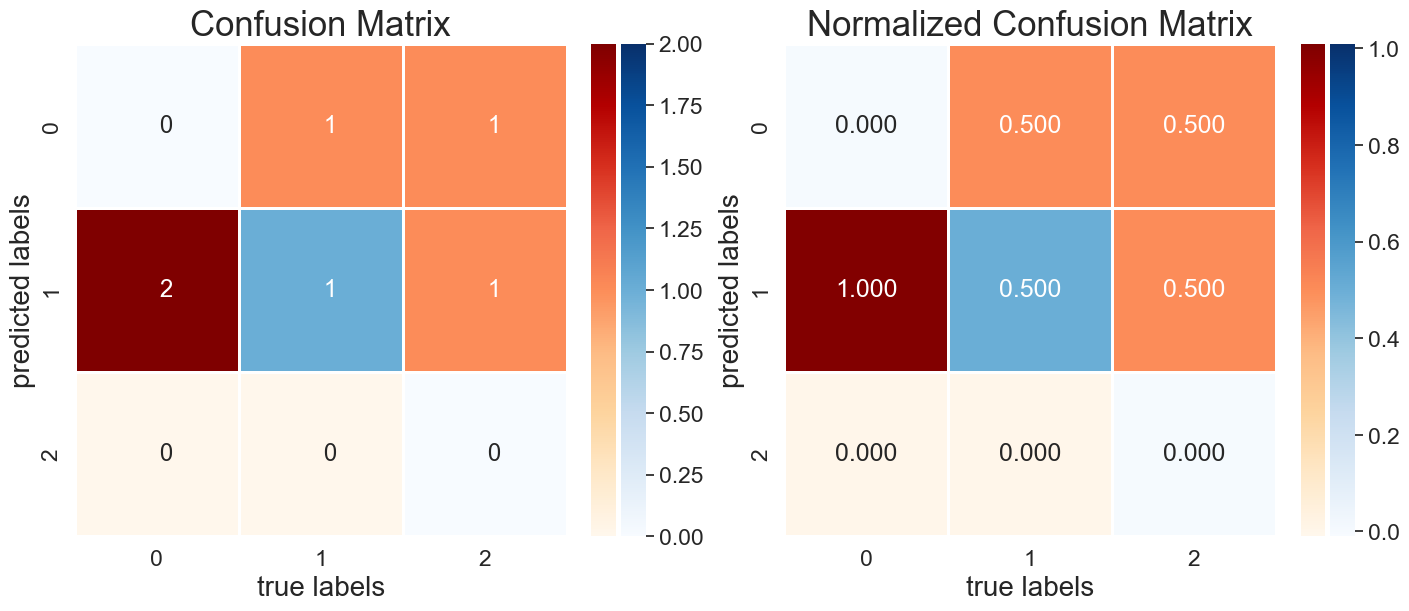

Balanced Accuracy:  16.67 %


In [ ]:
classlabels = y_test

scores = get_performances(
    loader2eval=testloader,
    Model=model_curr,
    device=device,
    nb_classes=nb_classes,
    return_scores=True,
    verbose=verbose,
    plot_confusion=True,
    class_labels=classlabels,
)
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

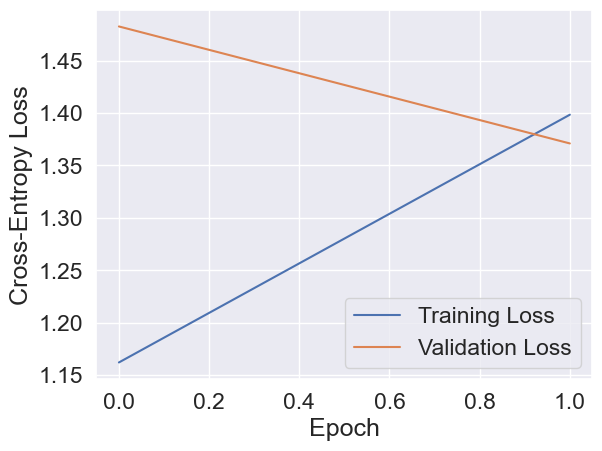

In [178]:
training_loss_curve = []
validation_loss_curve = []
# Iterate through the dictionary, filtering out entries with None values
for key, (train_loss, val_loss) in loss_summary.items():
    if train_loss is not None and val_loss is not None:
        training_loss_curve.append(train_loss)
        validation_loss_curve.append(val_loss)

scores["training_loss_curve"] = training_loss_curve
scores["validation_loss_curve"] = validation_loss_curve

plt.plot(training_loss_curve, label="Training Loss")
plt.plot(validation_loss_curve, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.show()

## Save the model


In [179]:
model_name = "xeeg_test_mini.pt"

dir_models = os.path.join(dir_shallownetXAI, "newmodels") + sep
model_path = os.path.join(dir_models, model_name)

dirResults = os.path.join(dir_shallownetXAI, "new_results") + sep
results_path = os.path.join(dirResults, f"{model_name[:-3]}_results.pickle")

In [180]:
results_path

'..\\..\\backend\\experiments_xeegnet\\shallownetXAI_main\\new_results\\xeeg_test_mini_results.pickle'

In [ ]:
print("model dir:", dir_models, os.path.isdir(dir_models))
print("model path:", model_path, os.path.abspath(model_path))
print("results dir:", dirResults, os.path.isdir(dirResults))
print(
    "results path:",
    results_path,
    os.path.abspath(results_path),
    os.path.exists(results_path),
)

model dir: ..\..\backend\experiments_xeegnet\shallownetXAI_main\newmodels\ True
model path: ..\..\backend\experiments_xeegnet\shallownetXAI_main\newmodels\xeeg_test_mini.pt c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI_main\newmodels\xeeg_test_mini.pt
results dir: ..\..\backend\experiments_xeegnet\shallownetXAI_main\new_results\ True
results path: ..\..\backend\experiments_xeegnet\shallownetXAI_main\new_results\xeeg_test_mini_results.pickle c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI_main\new_results\xeeg_test_mini_results.pickle True


In [183]:
save_model = False

if save_model:
    # Save the model
    model_curr.eval()
    model_curr.to(device="cpu")
    torch.save(model_curr.state_dict(), model_path)

    # Save the scores
    with open(results_path, "wb") as handle:
        pickle.dump(scores, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Compare training&inference times


In [ ]:
from time import time

In [ ]:
def inference(model, x: torch.Tensor | np.ndarray):
    model.eval()

    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x).float()
    with torch.no_grad():
        out = model(x)
    return out

In [ ]:
n_batches = 100
x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
cached_scc = torch.randn(n_batches, len(BANDS), Chans*(Chans-1)//2, dtype=torch.float32)

# xeegnet
current_time = time()
out = inference(xeegnet, x)
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for xeegnet")


# xeegnet_scc
current_time = time()
out = inference(xeegnet_scc, [x, cached_scc])
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for xeegnet_scc")

# shallownet
current_time = time()
out = inference(shallow_net, x)
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for shallownet")


Elapsed time for 100 batches: 0.0182 seconds for xeegnet
Elapsed time for 100 batches: 0.0126 seconds for xeegnet_scc
Elapsed time for 100 batches: 0.0701 seconds for shallownet


#### compare training time


In [ ]:
model_version = 200

n_max = 1500
n_max = None

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT

In [ ]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
split_index = model_version - 200

if not n_max:
    modelname = f"xeegnet_scc_model_v{model_version}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname
else:
    modelname = f"xeegnet_scc_model_v{model_version}_nmax{n_max}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname

split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"

participants_split = load_participant_splits(split_path=split_path)[str(split_index)]


df_metadata = load_metadata(dir_data=dir_data)
df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"
df_metadata.head()

df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"
df_metadata.head()

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded,participant_id_int,datasplit
0,sub-001,F,57,A,16,Alzheimer Disease Group,1,1,train
1,sub-002,F,78,A,22,Alzheimer Disease Group,1,2,val
2,sub-003,M,70,A,14,Alzheimer Disease Group,1,3,val
3,sub-004,F,67,A,20,Alzheimer Disease Group,1,4,val
4,sub-005,M,70,A,22,Alzheimer Disease Group,1,5,val


In [ ]:
participant_ids_train=participant_ids[:5]
participant_ids_val=participant_ids[5:8]

In [ ]:
trainloader, valloader, testloader, data_tuple = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    # n_max=1000,
)

gamma = 0.995
# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(
    patience=15, min_delta=1e-04, record_best_weights=True
)
validation_loss_args = []


Loaded derivative model windows: x shape (800, 19, 500), y shape (800,)
Loaded derivative model windows: x shape (547, 19, 500), y shape (547,)
Loaded derivative model windows: x shape (3164, 19, 500), y shape (3164,)


In [ ]:
trainloader_scc, valloader_scc, testloader_scc, data_tuple_scc = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    n_max=n_max,
    use_cached_scc=True,
    store=store,
    scc_params=params,
    dataset_id="ds004504",
    n_channels=Chans,
    source="derivatives",
    load_model_windows_for_participant=load_model_windows_for_participant,
)

print("trainloader_scc batches:", len(trainloader_scc))
print("valloader_scc batches:", len(valloader_scc))

Loaded x (800, 19, 500), scc (800, 7, 171), y (800,)
Loaded x (547, 19, 500), scc (547, 7, 171), y (547,)
Loaded x (3164, 19, 500), scc (3164, 7, 171), y (3164,)
trainloader_scc batches: 13
valloader_scc batches: 9


In [ ]:
## xeegnet_scc training

model_curr = build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate)

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader_scc,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader_scc,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for xeegnet_scc.")

epoch [1/5]
   val 9/9: 100%|███████████████| 22/22 [53.37 Batch/s, train_loss=2.45407, val_loss=2.14129]  
epoch [2/5]
   val 9/9: 100%|███████████████| 22/22 [63.86 Batch/s, train_loss=2.41197, val_loss=1.84079]  
epoch [3/5]
   val 9/9: 100%|███████████████| 22/22 [66.06 Batch/s, train_loss=2.39445, val_loss=1.71608]  
epoch [4/5]
   val 9/9: 100%|███████████████| 22/22 [68.18 Batch/s, train_loss=2.36259, val_loss=1.60173]  
epoch [5/5]
   val 9/9: 100%|███████████████| 22/22 [61.03 Batch/s, train_loss=2.29600, val_loss=1.51843]  
Training completed in 1.79 seconds for xeegnet_scc.


In [ ]:
# xeegnet training
model_curr = xeegnet

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader, 
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for xeegnet.")

epoch [1/5]
   val 9/9: 100%|███████████████| 22/22 [67.93 Batch/s, train_loss=1.77970, val_loss=2.78359]  
epoch [2/5]
   val 9/9: 100%|███████████████| 22/22 [69.38 Batch/s, train_loss=1.73629, val_loss=2.15271]  
epoch [3/5]
   val 9/9: 100%|███████████████| 22/22 [69.77 Batch/s, train_loss=1.66234, val_loss=2.02844]  
epoch [4/5]
   val 9/9: 100%|███████████████| 22/22 [52.57 Batch/s, train_loss=1.65616, val_loss=1.87270]  
epoch [5/5]
   val 9/9: 100%|███████████████| 22/22 [67.33 Batch/s, train_loss=1.63715, val_loss=1.90745]  
Training completed in 1.72 seconds for xeegnet.


In [ ]:
# #### shallow net

# # xeegnet training
# model_curr = shallow_net

# optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# current_time = time()

# loss_summary = train_model(
#     model=model_curr,
#     train_dataloader=trainloader,
#     epochs=5,
#     optimizer=optimizer,
#     loss_func=lossMulti,
#     lr_scheduler=scheduler,
#     EarlyStopper=earlystop,
#     validation_dataloader=valloader,
#     validation_loss_func=lossVal,
#     validation_loss_args=validation_loss_args,
#     verbose=verbose,
#     device=device,
#     return_loss_info=True,
# )

# elaspsed_time = time() - current_time
# print(f"Training completed in {elaspsed_time:.2f} seconds for shallow_net.")